# Fig 2 — Immune archetypes, tSNE landscape, and archetype survival

Execute cells in order.

Set `DLBCL_DATA_DIR` before the setup cell to override the data root.
Example: `DLBCL_DATA_DIR = '/path/to/data'`

In [1]:
%matplotlib inline

import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dlbcl.notebook_setup import run_notebook_setup

_ctx = run_notebook_setup('discovery_archetype', 'fig2')
REPO_ROOT = _ctx.repo_root
_paths = _ctx.paths
FIG_DIR = _ctx.fig_dir
adata = _ctx.adata
arch_df = _ctx.arch_df
pred = _ctx.pred
gep = _ctx.gep
surv = _ctx.surv
archetype_label = _ctx.archetype_label
PATIENT_SUBSET = _ctx.patient_subset
OUTDIR = FIG_DIR
OUTDIR.mkdir(parents=True, exist_ok=True)

# Override data root: export DLBCL_DATA_DIR=/path/to/data before running.
print(f"AnnData: {_paths.adata_path}")
print(f"Figures: {FIG_DIR}")

import gc

import pandas as pd
import scanpy as sc

ADATA_PATH = _paths.adata_path

# tSNE panel constants and filtered single-cell subset.
import gc

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from dlbcl.dlbcl_io import consolidate_embedded_case_classifications, log_wrote, log_saved, rel_path
from dlbcl.phenotype_labels import ensure_phenotype_30_labels, read_celltype_colormap_30
from dlbcl.tsne_figures import show_inline_preview

DATA_DIR = _paths.data_dir
ADATA_PATH = _paths.adata_path
ARCH_PATH = _paths.arch_path
FILTERING_STATUS_COL = "filtering_status"
FILTERING_KEEP_VALUE = "Unfiltered"
TSNE_BASIS = "tsne_all"
DOWNSAMPLE_FRAC = 1
PLOT_SEED = 42
INLINE_PREVIEW_DPI = 96
INLINE_PREVIEW_MAX_WIDTH = 900
INLINE_PREVIEW_JPEG_QUALITY = 72

from dlbcl.archetype_heatmap import (
    filter_phenotypes,
    infer_annotation_type,
    make_categorical_color_series,
    make_continuous_color_series,
    rgb_to_hex,
    zscore_rows,
)
import dlbcl.transcriptome_de as tde
from dlbcl.dlbcl_io import CLUSTER_NAME_MAP, ARCHETYPE_DISCOVERY_EXCLUDE_PATIENT_IDS
from dlbcl.phenotype_labels import PHENOTYPE_30_HEATMAP_EXCLUDE_TERMS as filter_terms
from dlbcl.tsne_figures import (
    configure_tsne_matplotlib,
    downsample_indices,
    map_patient_column,
    plot_tsne,
    sort_adata_by_obs_category,
    valid_label_mask,
)

configure_tsne_matplotlib()
exclude_patient_ids = sorted(ARCHETYPE_DISCOVERY_EXCLUDE_PATIENT_IDS)

adata_backed = ad.read_h5ad(_paths.adata_path, backed="r")
mask = (
    adata_backed.obs["patient_id"].isin(PATIENT_SUBSET)
    & (adata_backed.obs[FILTERING_STATUS_COL] == FILTERING_KEEP_VALUE)
)
adata_subset = adata_backed[mask].to_memory()
ensure_phenotype_30_labels(adata_subset)
ensure_phenotype_30_labels(adata)
del adata_backed
gc.collect()

if TSNE_BASIS not in adata_subset.obsm:
    raise KeyError(f"Missing obsm['{TSNE_BASIS}']; keys: {list(adata_subset.obsm.keys())}")

adata_subset = consolidate_embedded_case_classifications(
    adata_subset, _paths, repo_root=REPO_ROOT
)
print(
    f"Cells: {adata_subset.n_obs:,} | patients: {adata_subset.obs['patient_id'].nunique()}"
)

from IPython.display import display
from dlbcl.dlbcl_io import log_wrote, log_saved, rel_path, write_supplementary_table
subset = None  # nb8 classifier associations: filtered AnnData or None for all patients

from dlbcl.discovery_km import (
    ENDPOINTS,
    KM_HORIZON_YEARS,
    plot_km_by_archetype,
    plot_km_by_location,
)


AnnData: /Users/troynoordenbos/code/public_repo/DLBCL_location_2026/data/DLBCL_location_2026.h5ad
Figures: /Users/troynoordenbos/code/public_repo/DLBCL_location_2026/figures/fig2


Cells: 1,192,844 | patients: 64


## Fig 2 — panel overview

| Panel | Description |
|-------|-------------|
| 2A–D | Genomic classifier tSNE landscape (phenotype, location, LymphGen, DLBclass) |
| (discovery) | Immune-archetype phenotype-density heatmap + per-location composition pies |
| 2F–G | Kaplan–Meier survival by immune archetype (+ supplemental PFS) |

**Data:** `data/DLBCL_location_2026.h5ad` — set `DLBCL_DATA_DIR` to override the data root.

## Fig 2A — 16-class phenotype tSNE

In [2]:
adata_sorted = sort_adata_by_obs_category(adata_subset, "phenotype_16_bm")
adata_plot = adata_sorted[downsample_indices(adata_sorted.n_obs)]

plot_tsne(
    adata_plot,
    color="phenotype_16_bm",
    title="tSNE — 16-class phenotype",
    out_stem=FIG_DIR / "fig2A_tsne_phenotype16_bm",
    palette=adata_sorted.uns["celltype_colormap_16"],
)


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


figures/fig2/fig2A_tsne_phenotype16_bm.svg


## Fig 2B — tumor location tSNE

In [3]:
map_patient_column(adata_subset, "Location", "location")
adata_filt = adata_subset[valid_label_mask(adata_subset.obs["location"])]
adata_plot = adata_filt[downsample_indices(adata_filt.n_obs)]
rng = np.random.default_rng(PLOT_SEED)
sort_order = rng.permutation(adata_plot.n_obs).tolist()

plot_tsne(
    adata_plot,
    color="location",
    title="tSNE — tumor location",
    out_stem=FIG_DIR / "fig2B_tsne_location",
    palette=["#0072B2", "#E69F00", "#009E73", "#CC79A7"],
    sort_order=sort_order,
)


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


figures/fig2/fig2B_tsne_location.svg


## Fig 2C — LymphGen tSNE

In [4]:
map_patient_column(adata_subset, "Lymphgen", "Lymphgen")
adata_filt = adata_subset[valid_label_mask(adata_subset.obs["Lymphgen"])]
adata_plot = adata_filt[downsample_indices(adata_filt.n_obs)]
rng = np.random.default_rng(PLOT_SEED)
sort_order = rng.permutation(adata_plot.n_obs).tolist()

plot_tsne(
    adata_plot,
    color="Lymphgen",
    title="tSNE — LymphGen",
    out_stem=FIG_DIR / "fig2C_tsne_lymphgen",
    palette=["#ff7f0e", "#1f77b4", "#2ca02c", "#9467bd", "#9966cc", "lightgrey", "#d62728"],
    sort_order=sort_order,
)


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


figures/fig2/fig2C_tsne_lymphgen.svg


## Fig 2D — DLBclass tSNE

In [5]:
map_patient_column(adata_subset, "DLBclass", "DLBclass")
adata_filt = adata_subset[valid_label_mask(adata_subset.obs["DLBclass"])]
adata_plot = adata_filt[downsample_indices(adata_filt.n_obs)]
rng = np.random.default_rng(PLOT_SEED)
sort_order = rng.permutation(adata_plot.n_obs).tolist()

plot_tsne(
    adata_plot,
    color="DLBclass",
    title="tSNE — DLBclass",
    out_stem=FIG_DIR / "fig2D_tsne_dlbclass",
    palette=["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"],
    sort_order=sort_order,
)


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


figures/fig2/fig2D_tsne_dlbclass.svg


## Archetype discovery — phenotype-density heatmap

#### Setup — paths, filters, and color maps

In [6]:
# Fig 2F heatmap: imports and global plot settings
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns

from scipy.stats import zscore
from scipy.cluster.hierarchy import fcluster
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm

from matplotlib.ticker import LogFormatterMathtext


mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"
sns.set_style("white", {'axes.grid': False})

# -----------------------------
# paths
# -----------------------------
figname_pdf = str(FIG_DIR / "fig2E_archetype_density_heatmap.pdf")
figname_png = str(FIG_DIR / "fig2E_archetype_density_heatmap.png")
legend_pdf = str(FIG_DIR / "fig2E_archetype_density_heatmap_legend_vert.pdf")
legend_png = str(FIG_DIR / "fig2E_archetype_density_heatmap_legend_vert.png")

# -----------------------------
# user settings
# -----------------------------
from dlbcl.dlbcl_io import ARCHETYPE_DISCOVERY_EXCLUDE_PATIENT_IDS
exclude_patient_ids = sorted(ARCHETYPE_DISCOVERY_EXCLUDE_PATIENT_IDS)
from dlbcl.phenotype_labels import PHENOTYPE_30_HEATMAP_EXCLUDE_TERMS as filter_terms
force_categorical = {
    "Location",
    "HLAABC",
    "HLADR",
    "COO_NanoString_update",
}

category_orders = {
    "Location": ["PCNS", "bone", "nodal", "testis"],
    "HLAABC": ["loss", "retained"],
    "HLADR": ["loss", "retained"],
    "COO_NanoString_update": ["ABC", "Intermediate", "GCB"],
}
path_cols_patient = [
    'HLAABC', 'HLADR'
]

meta_cols_summary = [
    'Location',
    'COO_NanoString_update'
]

# explicit annotation order for plotting (top-to-bottom in col_colors)
annotation_order = [

    'HLADR',
    'HLAABC',
    'COO_NanoString_update',
    'Location',
]

# columns that should always be interpreted as categorical or continuous
force_categorical = {
    'Location',
    'HLA_class_state',
    'HLAABC',
    'HLADR'
}

force_continuous = {
}

max_unique_for_categorical = 8
missing_color = '#d9d9d9'

# category ordering where desired
category_orders = {
    'Location': ['PCNS', 'bone', 'nodal', 'testis']
}

# manual color maps where desired

custom_color_maps = {
    'Location': {
        'bone': "#ff7f0e",      # warm orange
        'nodal': "#2ca02c",     # green
        'PCNS': "#1f77b4",      # blue
        'testis': "#d62728"     # red
    },
    "HLADR": {
        "loss": "#b2182b", #red
        "retained": "#2166ac", #blue
    },

    "HLA_class_state": {
        "HLA-I+/HLA-II+": "#d99227",
        "HLA-I-/HLA-II+": "#9d8ac7",
        "HLA-I-/HLA-II-": "#6f3b8f",
    },

    "HLAABC": {
        "loss": "#b2182b",
        "retained": "#2166ac",
    },

    "COO_NanoString_update": {
        "ABC": "#08306b",
        "Intermediate": "#cc99ff",
        "GCB": "#f28e2b",
    },
}    

continuous_cmaps = {
}



#### Step 1 — phenotype × patient density matrices (area-normalized counts + z-scores)

In [7]:
# -----------------------------
# 1. build phenotype x patient matrices
# -----------------------------
_adata_heat = adata_subset.copy() if "adata_subset" in globals() else adata.copy()
if "PATIENT_SUBSET" in globals():
    _adata_heat = _adata_heat[_adata_heat.obs["patient_id"].astype(str).isin(PATIENT_SUBSET)].copy()
adata = _adata_heat
obs = adata.obs[['patient_id', 'phenotype_30_clean', 'Area']].copy()

area_sum = obs.groupby('patient_id', observed=False)['Area'].sum()

count_df = (
    obs.groupby(['patient_id', 'phenotype_30_clean'], observed=False)
       .size()
       .rename('count')
       .reset_index()
)

count_df['Area'] = count_df['patient_id'].map(area_sum)
count_df['count'] = pd.to_numeric(count_df['count'], errors='coerce')
count_df['Area'] = pd.to_numeric(count_df['Area'], errors='coerce')
count_df['normalized_count'] = count_df['count'] / count_df['Area']

heatmap_data = (
    count_df.pivot(index='phenotype_30_clean', columns='patient_id', values='normalized_count')
            .fillna(0)
)

raw_count_data = (
    count_df.pivot(index='phenotype_30_clean', columns='patient_id', values='count')
            .fillna(0)
)

heatmap_data = heatmap_data.loc[:, ~heatmap_data.columns.isin(exclude_patient_ids)]
raw_count_data = raw_count_data.loc[:, ~raw_count_data.columns.isin(exclude_patient_ids)]
from dlbcl.dlbcl_io import is_archetype_discovery_excluded
_ref_cols = [c for c in heatmap_data.columns if is_archetype_discovery_excluded(c)]
heatmap_data = heatmap_data.drop(columns=_ref_cols, errors="ignore")
raw_count_data = raw_count_data.drop(columns=_ref_cols, errors="ignore")

heatmap_data = filter_phenotypes(heatmap_data, filter_terms)
raw_count_data = filter_phenotypes(raw_count_data, filter_terms)

zscored_data = zscore_rows(heatmap_data)



# -----------------------------
# 2. row color bar: total cell count per phenotype (LOG SCALE)
# -----------------------------
total_cells_per_phenotype = raw_count_data.sum(axis=1)


#### Step 2 — row side bar: total cell count per phenotype (log scale)

In [8]:

phenotype_to_alias1 = adata.uns.get('phenotype_to_alias1', {})

zscored_data = zscored_data.rename(index=phenotype_to_alias1)

total_cells_per_phenotype = raw_count_data.sum(axis=1)
total_cells_per_phenotype = total_cells_per_phenotype.rename(index=phenotype_to_alias1)
total_cells_per_phenotype = total_cells_per_phenotype.reindex(zscored_data.index)

# only valid positive values for log scaling
valid_counts = total_cells_per_phenotype.dropna()
positive_counts = valid_counts[valid_counts > 0]

row_cmap = sns.light_palette("navy", as_cmap=True)

if len(positive_counts) == 0:
    # fallback (no valid log values)
    row_norm = plt.Normalize(vmin=0, vmax=1)
    row_color_series = pd.Series("#808080", index=zscored_data.index)

else:
    vmin = positive_counts.min()
    vmax = positive_counts.max()

    # avoid degenerate log scale
    if vmin == vmax:
        vmin = max(vmin / 10, 1)
        vmax = vmax * 10

    row_norm = LogNorm(vmin=vmin, vmax=vmax)

    row_color_series = total_cells_per_phenotype.map(
        lambda x: "#808080" if pd.isna(x) or x <= 0
        else mcolors.to_hex(row_cmap(row_norm(x)))
    )

row_colors = pd.DataFrame(
    {"Total_Cell_Count": row_color_series},
    index=zscored_data.index
)
# -----------------------------
# 3. collect metadata
# -----------------------------
patient_path = pd.DataFrame(adata.uns["case_path"]).copy()
patient_summary = pd.DataFrame(adata.uns["case_classifications"]).copy()



#### Step 3 — patient metadata for column annotations (HLA, COO, location)

In [9]:
# Merge case_classifications + case_path; normalize location and HLA labels
def set_patient_index(df):
    df = df.copy()
    if "patient_id" in df.columns:
        df["patient_id"] = df["patient_id"].astype(str)
        df = df.set_index("patient_id")
    df.index = df.index.astype(str)
    df.index.name = "patient_id"
    return df

patient_path = set_patient_index(patient_path)
patient_summary = set_patient_index(patient_summary)

# keep only required columns
patient_path = patient_path[
    [c for c in ["HLAABC", "HLADR"] if c in patient_path.columns]
].copy()

patient_summary = patient_summary[
    [c for c in ["COO_NanoString_update", "Location"] if c in patient_summary.columns]
].copy()

# normalize location labels
location_replace = {
    "pBONE": "bone",
    "polyOST": "bone",
    "disseminated": "bone",
}

if "Location" in patient_summary.columns:
    patient_summary["Location"] = patient_summary["Location"].replace(location_replace)

# combine annotations
annotation_df = patient_summary.join(patient_path, how="outer")

# clean HLA calls
def clean_hla_call(s):
    return (
        s.astype("object")
         .replace({
             0: "loss",
             1: "retained",
             0.0: "loss",
             1.0: "retained",
             "0": "loss",
             "1": "retained",
             "0.0": "loss",
             "1.0": "retained",
             "UNK": pd.NA,
             "unknown": pd.NA,
             "Unknown": pd.NA,
             "nan": pd.NA,
         })
    )

for col in ["HLAABC", "HLADR"]:
    if col in annotation_df.columns:
        annotation_df[col] = clean_hla_call(annotation_df[col])

if {"HLAABC", "HLADR"}.issubset(annotation_df.columns):
    hla_annot = tde.add_hla_class_group(annotation_df)
    annotation_df["HLA_class_state"] = hla_annot["hla_class_group"].astype("object")

# align to heatmap columns
annotation_df = annotation_df.reindex(zscored_data.columns)

# enforce plotting order
annotation_order = [
    "HLA_class_state",
    "HLADR",
    "HLAABC",
    "COO_NanoString_update",
    "Location",
]

annotation_df = annotation_df[
    [c for c in annotation_order if c in annotation_df.columns]
].copy()

# ============================================================
# Fresh column annotations, including tumor density
# ============================================================

# Remove stale notebook objects that can silently interfere


#### Step 4 — tumor area fraction + column color strips

In [10]:
# Tumor_Area_Fraction = CD20+ cellular area / total cellular area per patient
for _old in [
    "col_colors",
    "column_legend_handles",
    "column_color_maps",
    "column_continuous_specs",
]:
    if _old in globals():
        del globals()[_old]

# -----------------------------
# Tumor area fraction annotation
# -----------------------------
obs_for_tumor = adata.obs[["patient_id", "phenotype_30_clean", "Area"]].copy()
obs_for_tumor["patient_id"] = obs_for_tumor["patient_id"].astype(str)
obs_for_tumor["phenotype_30_clean"] = obs_for_tumor["phenotype_30_clean"].astype(str)
obs_for_tumor["Area"] = pd.to_numeric(obs_for_tumor["Area"], errors="coerce")

# denominator: total cellular area per patient
total_cellular_area = (
    obs_for_tumor
    .groupby("patient_id", observed=False)["Area"]
    .sum()
)

# numerator: summed area of all CD20* tumor phenotypes
is_cd20 = (
    obs_for_tumor["phenotype_30_clean"]
    .str.lower()
    .str.startswith("cd20", na=False)
)

tumor_cell_area = (
    obs_for_tumor.loc[is_cd20]
    .groupby("patient_id", observed=False)["Area"]
    .sum()
)

tumor_area_fraction = (
    tumor_cell_area
    .div(total_cellular_area)
    .replace([np.inf, -np.inf], np.nan)
)

tumor_area_fraction.name = "Tumor_Area_Fraction"

annotation_df = annotation_df.copy()
annotation_df["Tumor_Area_Fraction"] = tumor_area_fraction
annotation_df = annotation_df.reindex(zscored_data.columns)

# -----------------------------
# Build fresh col_colors
# -----------------------------
force_categorical = {
    "Location",
    "HLA_class_state",
    "HLAABC",
    "HLADR",
    "COO_NanoString_update",
}

force_continuous = {
    "Tumor_Area_Fraction",
}

continuous_cmaps = {
    "Tumor_Area_Fraction": "Grays",
}

col_colors = pd.DataFrame(index=annotation_df.index)
column_legend_handles = []
column_color_maps = {}
column_continuous_specs = {}

for col in annotation_df.columns:
    ann_type = infer_annotation_type(
        annotation_df[col],
        force_continuous=force_continuous,
        force_categorical=force_categorical,
        max_unique_for_categorical=max_unique_for_categorical,
    )

    if ann_type == "continuous":
        cmap_name = continuous_cmaps.get(col, "viridis")
        col_colors[col] = make_continuous_color_series(
            annotation_df[col],
            cmap=cmap_name,
            missing_color=missing_color,
        )

        s_num = pd.to_numeric(annotation_df[col], errors="coerce")
        valid = s_num.dropna()

        if len(valid) > 0:
            column_continuous_specs[col] = {
                "vmin": valid.min(),
                "vmax": valid.max(),
                "cmap": cmap_name,
            }

    else:
        level_order = category_orders.get(col, None)
        overrides = custom_color_maps.get(col, None)

        color_series, color_map = make_categorical_color_series(
            annotation_df[col],
            palette="tab20",
            missing_color=missing_color,
            level_order=level_order,
            overrides=overrides,
        )

        col_colors[col] = color_series
        column_color_maps[col] = color_map

        for level, color in color_map.items():
            column_legend_handles.append(
                mpatches.Patch(
                    color=color,
                    label=f"{col}: {level}",
                )
            )

# explicit missing-data legend
column_legend_handles.append(
    mpatches.Patch(color=missing_color, label="Missing")
)

# sanity checks
assert col_colors.index.equals(zscored_data.columns), "col_colors index does not match heatmap columns"
assert list(col_colors.columns) == list(annotation_df.columns), "col_colors columns do not match annotation_df"

print("Fresh column annotations:")
display(annotation_df.head())

print("\nTumor density summary:")
display(annotation_df["Tumor_Area_Fraction"].describe())
# -----------------------------
# 6. rename phenotypes before plotting
# -----------------------------
phenotype_to_alias1 = adata.uns.get('phenotype_to_alias1', {})
zscored_data = zscored_data.rename(index=phenotype_to_alias1)


Fresh column annotations:


,HLA_class_state,HLADR,HLAABC,Location,Tumor_Area_Fraction
patient_id,,,,,
T1,HLA-I-/HLA-II-,loss,loss,PCNS,0.341903
T10,HLA-I+/HLA-II+,retained,retained,PCNS,0.217844
T12,HLA-I-/HLA-II+,retained,loss,PCNS,0.426291
T13,HLA-I-/HLA-II-,loss,loss,PCNS,0.313500
T14,HLA-I-/HLA-II+,retained,loss,PCNS,0.441928



Tumor density summary:


count    64.000000
mean      0.316917
std       0.120587
min       0.073861
25%       0.231342
50%       0.318438
75%       0.392029
max       0.626230
Name: Tumor_Area_Fraction, dtype: float64

#### Step 5 — clustermap, archetype cuts, and split lines (Ward clustering on z-scored phenotype densities)

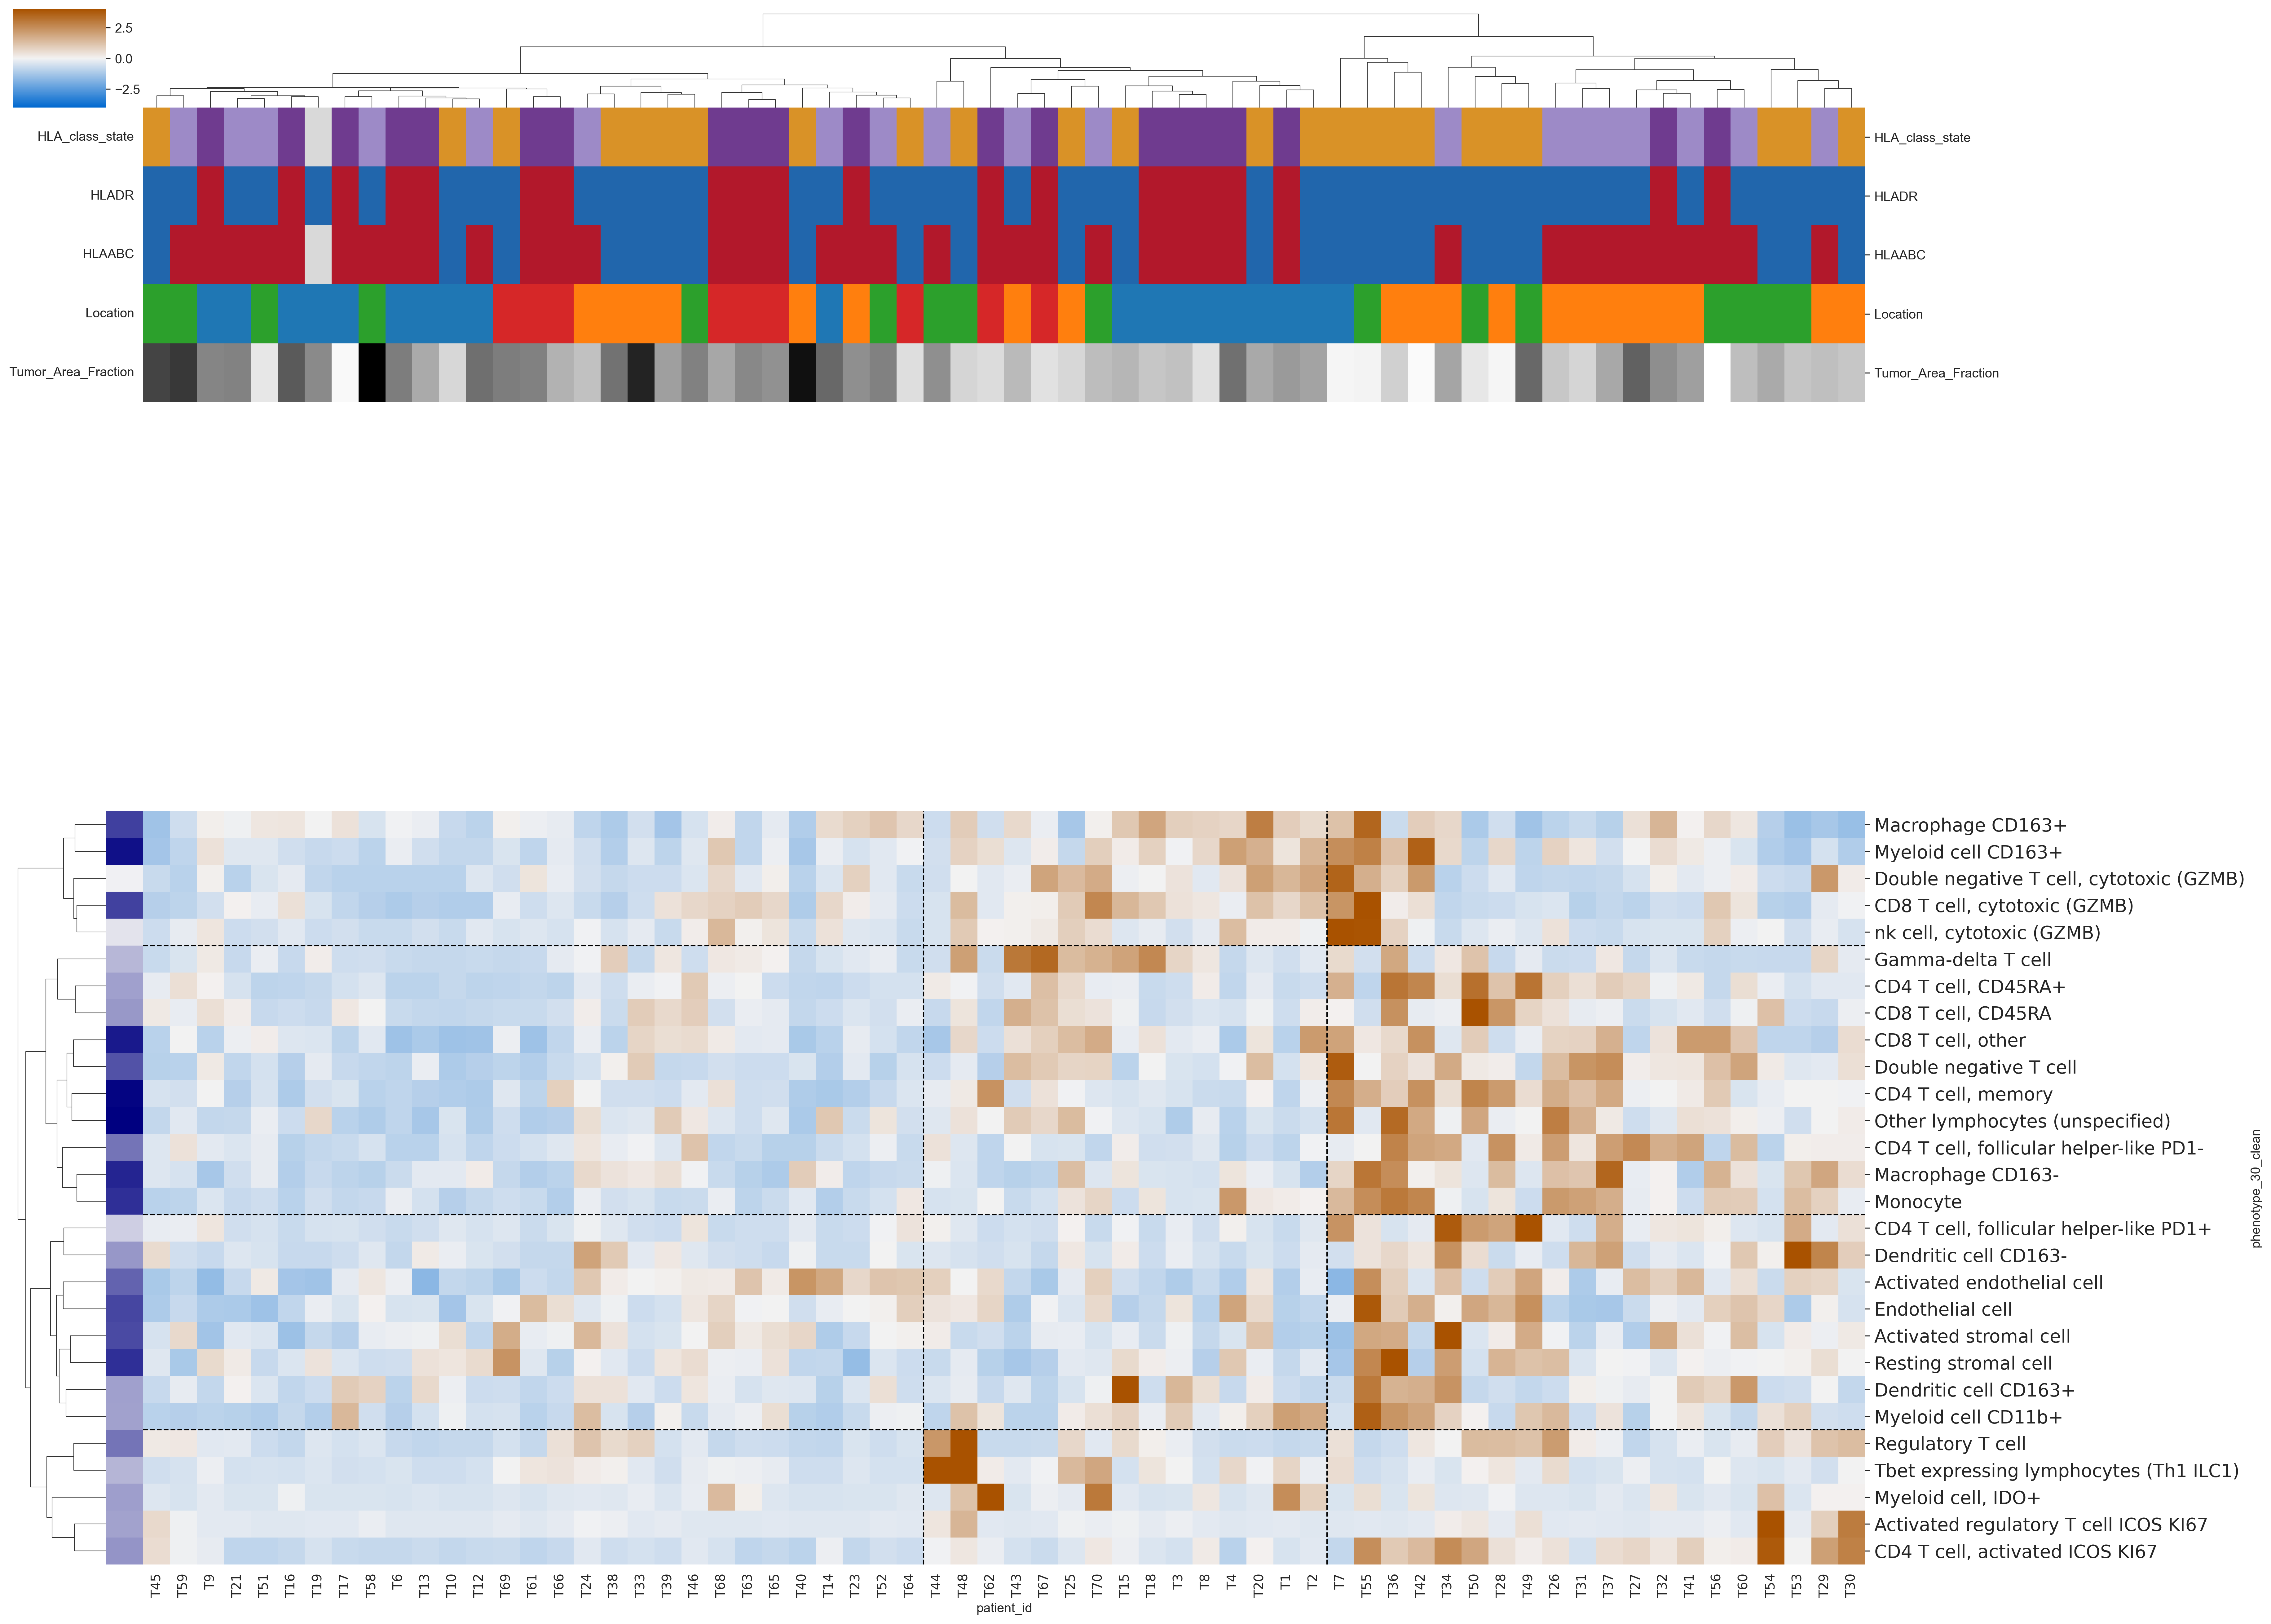

In [11]:
# Apply display aliases, draw clustermap, then square cells and align dendrogram strips
row_colors = row_colors.reindex(zscored_data.index)


# -----------------------------
# 7. plot
# -----------------------------
row_label_fontsize = 14
row_label_fontfamily = "DejaVu Sans"
col_label_fontsize = 10
col_label_fontfamily = "DejaVu Sans"

custom_cmap = sns.diverging_palette(255, 30, s=100, l=45, sep=2, center="light", as_cmap=True)
#custom_cmap = sns.color_palette("inferno", as_cmap=True)
g = sns.clustermap(
    zscored_data,
    cmap=custom_cmap,
    center=0,
    vmin=-4,
    vmax=4,
    method="ward",
    metric="euclidean",
    col_colors=col_colors,
    row_colors=row_colors[["Total_Cell_Count"]],
    figsize=(24, 24),
    linewidths=0,
    dendrogram_ratio=(0.05, 0.05),
    colors_ratio=(0.02, 0.03),
    xticklabels=True,
    yticklabels=True,
    row_cluster=True,
    col_cluster=True,
    cbar_pos=(0.92, 0.20, 0.02, 0.25)
)

# -----------------------------
# 7a. basic label formatting
# -----------------------------
for lab in g.ax_heatmap.get_yticklabels():
    lab.set_fontsize(row_label_fontsize)
    lab.set_fontfamily(row_label_fontfamily)

for lab in g.ax_heatmap.get_xticklabels():
    lab.set_fontsize(col_label_fontsize)
    lab.set_fontfamily(col_label_fontfamily)
    lab.set_rotation(90)

if g.ax_col_colors is not None:
    g.ax_col_colors.tick_params(axis="x", bottom=False, labelbottom=False)
    g.ax_col_colors.tick_params(axis="y", left=False, labelleft=True, labelsize=10)

if g.ax_row_colors is not None:
    g.ax_row_colors.tick_params(axis="x", bottom=False, labelbottom=False)
    g.ax_row_colors.tick_params(axis="y", left=False, labelleft=False)

# -----------------------------
# 7b. final layout FIRST
# -----------------------------
g.fig.subplots_adjust(right=0.88, top=0.93, bottom=0.05, left=0.05)

# -----------------------------
# 7c. force square cells via box aspect
# -----------------------------
n_rows, n_cols = zscored_data.shape
g.ax_heatmap.set_box_aspect(n_rows / n_cols)

# let matplotlib update positions
g.fig.canvas.draw()

# -----------------------------
# 7d. now realign row/col annotation strips
# -----------------------------
hm = g.ax_heatmap.get_position()
# keep row dendrogram glued to heatmap too
if g.ax_row_dendrogram is not None:
    rd = g.ax_row_dendrogram.get_position()
    rcw = g.ax_row_colors.get_position().width if g.ax_row_colors is not None else 0

    g.ax_row_dendrogram.set_position([
        hm.x0 - rcw - rd.width,   # left of row_colors (or directly left of heatmap if no row_colors)
        hm.y0,                    # same bottom
        rd.width,                 # preserve dendrogram width
        hm.height                 # same height as heatmap
    ])
if g.ax_row_colors is not None:
    rc = g.ax_row_colors.get_position()
    g.ax_row_colors.set_position([
        hm.x0 - rc.width,   # immediately left of heatmap
        hm.y0,              # same bottom
        rc.width,           # preserve strip width
        hm.height           # same height
    ])

if g.ax_col_colors is not None:
    cc = g.ax_col_colors.get_position()
    g.ax_col_colors.set_position([
        hm.x0,              # same left
        cc.y0,              # preserve its vertical placement
        hm.width,           # same width as heatmap
        cc.height           # preserve strip height
    ])

# draw once more after repositioning
g.fig.canvas.draw()


# Cut column dendrogram into 4 groups; collapse groups >3 → archetype 3 based on dendogram; add row split lines
# 5 dendrogram-derived clusters
labels = fcluster(g.dendrogram_col.linkage, t=4, criterion="maxclust")
order = np.array(g.dendrogram_col.reordered_ind)

# patient IDs in dendrogram left-to-right order
ordered_patients = np.array(zscored_data.columns)[order]

# cluster labels in dendrogram left-to-right order
ordered_labels = labels[order]

# relabel clusters left-to-right as 1,2,3,4
seen = {}
ordered_relabeled = []

for x in ordered_labels:
    if x not in seen:
        seen[x] = len(seen) + 1
    ordered_relabeled.append(seen[x])

ordered_relabeled = np.array(ordered_relabeled, dtype=int)

# zip ordered patients with ordered relabeled labels
adata.uns["abundance_cluster_30_raw"] = dict(
    zip(ordered_patients, ordered_relabeled)
)

# collapse groups >3 → archetype 3
ordered_relabeled[ordered_relabeled > 3] = 3

# map back to original column order and store
final_labels = np.empty_like(labels)
final_labels[order] = ordered_relabeled
adata.uns["abundance_cluster_30"] = dict(zip(zscored_data.columns, final_labels.astype(int)))

# draw column split lines on the rendered heatmap
for line in list(g.ax_heatmap.lines):
    line.remove()

for i in np.where(np.diff(ordered_relabeled) != 0)[0] + 1:
    g.ax_heatmap.axvline(i, color="black", linestyle="--", linewidth=1)

# add row split lines
row_linkage = g.dendrogram_row.linkage
groups_r = fcluster(row_linkage, t=4, criterion='maxclust')
leaves_order_r = g.dendrogram_row.reordered_ind
ordered_groups_r = groups_r[leaves_order_r]

row_boundaries = [
    i for i in range(1, len(ordered_groups_r))
    if ordered_groups_r[i] != ordered_groups_r[i - 1]
]

for i in row_boundaries:
    g.ax_heatmap.axhline(i, color='black', linestyle='--', linewidth=1)



#### Step 6 — persist dendrogram order and row labels in `adata.uns`

In [12]:
# -----------------------------
# 10. save clustering outputs
# -----------------------------
adata.uns['row_dendrogram_cntr'] = g.dendrogram_row.linkage
adata.uns['col_dendrogram_cntr'] = g.dendrogram_col.linkage

reordered_indices = g.dendrogram_row.reordered_ind
reordered_labels = [zscored_data.index[i] for i in reordered_indices]

adata.uns['row_dendrogram_cntr_labels'] = reordered_labels
adata.uns['index_row_dendogram_cntr'] = pd.DataFrame({
    'original_index': reordered_indices,
    'alias_label': reordered_labels
})



#### Step 7 — standalone legends (vertical + horizontal layouts)

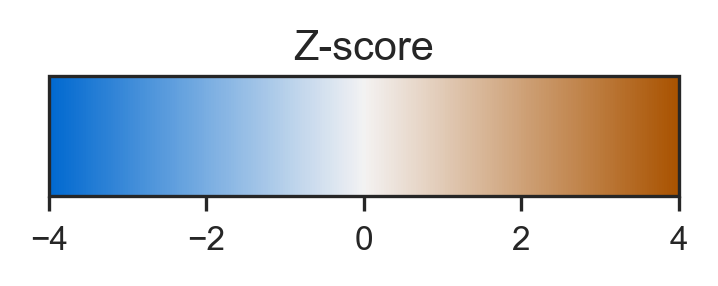

In [13]:
# Build separate legend figures for z-score, cell-count, tumor-fraction, and categorical bars
# -----------------------------
# 11. optional legends
# -----------------------------
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import LogFormatterMathtext

base = os.path.splitext(figname_pdf)[0]
legend_vert_pdf = base + "_legend_vertical.pdf"
legend_vert_png = base + "_legend_vertical.png"

legend_hor_pdf = base + "_legend_horizontal.pdf"
legend_hor_png = base + "_legend_horizontal.png"


# -----------------------------
# log-decade bounds (same as before)
# -----------------------------
positive = valid_counts[valid_counts > 0]

row_vmin_decade = 10 ** np.floor(np.log10(positive.min()))
row_vmax_decade = 10 ** np.ceil(np.log10(positive.max()))

row_norm_legend = LogNorm(vmin=row_vmin_decade, vmax=row_vmax_decade)

row_ticks = 10 ** np.arange(
    np.log10(row_vmin_decade),
    np.log10(row_vmax_decade) + 1
)

# -----------------------------
# figure layout (vertical stack)
# -----------------------------
fig_leg = plt.figure(figsize=(4, 6))

# 1) column legend (top)
ax_top = fig_leg.add_axes([0.05, 0.72, 0.9, 0.25])
ax_top.axis("off")

ax_top.legend(
    handles=column_legend_handles,
    loc="center",
    fontsize=8,
    ncol=2,   # fewer columns for vertical layout
    frameon=False
)

# 2) heatmap colorbar (middle)
ax_heat_cbar = fig_leg.add_axes([0.25, 0.42, 0.2, 0.22])

heat_sm = ScalarMappable(
    norm=Normalize(vmin=-4, vmax=4),
    cmap=custom_cmap
)
heat_sm.set_array([])

heat_cbar = plt.colorbar(
    heat_sm,
    cax=ax_heat_cbar,
    orientation="vertical"
)
heat_cbar.set_label("Z-score", fontsize=10)
heat_cbar.ax.tick_params(labelsize=8)

# 3) row annotation colorbar (bottom)
ax_row_cbar = fig_leg.add_axes([0.65, 0.42, 0.2, 0.22])

row_sm = ScalarMappable(
    norm=row_norm_legend,
    cmap=row_cmap
)
row_sm.set_array([])

row_cbar = plt.colorbar(
    row_sm,
    cax=ax_row_cbar,
    orientation="vertical",
    format=LogFormatterMathtext(base=10)
)
row_cbar.set_label("Total cell count", fontsize=10)
row_cbar.ax.tick_params(labelsize=8)
row_cbar.set_ticks(row_ticks)
if "Tumor_Area_Fraction" in column_continuous_specs:
    spec = column_continuous_specs["Tumor_Area_Fraction"]

    ax_tumor_cbar = fig_leg.add_axes([0.42, 0.12, 0.45, 0.08])

    tumor_sm = ScalarMappable(
        norm=Normalize(vmin=spec["vmin"], vmax=spec["vmax"]),
        cmap=plt.get_cmap(spec["cmap"]),
    )
    tumor_sm.set_array([])

    tumor_cbar = plt.colorbar(
        tumor_sm,
        cax=ax_tumor_cbar,
        orientation="horizontal",
    )
    tumor_cbar.set_label("Tumor area density\narea CD20+ cells / total cellular area", fontsize=9)
    tumor_cbar.ax.tick_params(labelsize=8)
# -----------------------------
# save
# -----------------------------
fig_leg.savefig(legend_pdf, bbox_inches="tight")
fig_leg.savefig(legend_png, dpi=300, bbox_inches="tight")
plt.close(fig_leg)
# -----------------------------
# HORIZONTAL LEGEND
# -----------------------------
fig_leg = plt.figure(figsize=(6, 2))  # wide + short

# 1) heatmap colorbar (left)
ax_heat_cbar = fig_leg.add_axes([0.10, 0.45, 0.35, 0.20])  
# [left, bottom, width, height] → width >> height

heat_sm = ScalarMappable(
    norm=Normalize(vmin=-4, vmax=4),
    cmap=custom_cmap
)
heat_sm.set_array([])

heat_cbar = plt.colorbar(
    heat_sm,
    cax=ax_heat_cbar,
    orientation="horizontal"
)
heat_cbar.set_label("Z-score", fontsize=10)
heat_cbar.ax.tick_params(labelsize=8)

# optional: move label above for cleaner horizontal layout
heat_cbar.ax.xaxis.set_label_position('top')
heat_cbar.ax.xaxis.set_ticks_position('bottom')


# -----------------------------
# VERTICAL LEGEND
# -----------------------------
fig_leg = plt.figure(figsize=(3.2, 5.0))

# 1) heatmap colorbar
ax_heat_cbar = fig_leg.add_axes([0.18, 0.42, 0.16, 0.35])

heat_sm = ScalarMappable(
    norm=Normalize(vmin=-4, vmax=4),
    cmap=custom_cmap
)
heat_sm.set_array([])

heat_cbar = plt.colorbar(
    heat_sm,
    cax=ax_heat_cbar,
    orientation="vertical"
)
heat_cbar.set_label("Z-score", fontsize=10)
heat_cbar.ax.tick_params(labelsize=8)

# 2) row annotation colorbar
ax_row_cbar = fig_leg.add_axes([0.58, 0.42, 0.16, 0.35])

row_sm = ScalarMappable(
    norm=row_norm_legend,
    cmap=row_cmap
)
row_sm.set_array([])

row_cbar = plt.colorbar(
    row_sm,
    cax=ax_row_cbar,
    orientation="vertical",
    format=LogFormatterMathtext(base=10)
)
row_cbar.set_label("Total cell count", fontsize=10)
row_cbar.ax.tick_params(labelsize=8)
row_cbar.set_ticks(row_ticks)

# 3) tumor area fraction colorbar
if "Tumor_Area_Fraction" in column_continuous_specs:
    spec = column_continuous_specs["Tumor_Area_Fraction"]

    ax_tumor_cbar = fig_leg.add_axes([0.22, 0.12, 0.58, 0.08])

    tumor_sm = ScalarMappable(
        norm=Normalize(vmin=spec["vmin"], vmax=spec["vmax"]),
        cmap=plt.get_cmap(spec["cmap"]),
    )
    tumor_sm.set_array([])

    tumor_cbar = plt.colorbar(
        tumor_sm,
        cax=ax_tumor_cbar,
        orientation="horizontal",
    )
    tumor_cbar.set_label(
        "Tumor area density\narea CD20+ cells / total cellular area",
        fontsize=9
    )
    tumor_cbar.ax.tick_params(labelsize=8)

# save vertical legend
fig_leg.savefig(legend_pdf, bbox_inches="tight")
fig_leg.savefig(legend_png, dpi=300, bbox_inches="tight")
plt.close(fig_leg)


# -----------------------------
# HORIZONTAL LEGEND
# -----------------------------
fig_leg = plt.figure(figsize=(7.2, 2.4))

# 1) heatmap colorbar
ax_heat_cbar = fig_leg.add_axes([0.08, 0.55, 0.25, 0.16])

heat_sm = ScalarMappable(
    norm=Normalize(vmin=-4, vmax=4),
    cmap=custom_cmap
)
heat_sm.set_array([])

heat_cbar = plt.colorbar(
    heat_sm,
    cax=ax_heat_cbar,
    orientation="horizontal"
)
heat_cbar.set_label("Z-score", fontsize=10)
heat_cbar.ax.tick_params(labelsize=8)
heat_cbar.ax.xaxis.set_label_position("top")
heat_cbar.ax.xaxis.set_ticks_position("bottom")

# 2) row annotation colorbar
ax_row_cbar = fig_leg.add_axes([0.39, 0.55, 0.25, 0.16])

row_sm = ScalarMappable(
    norm=row_norm_legend,
    cmap=row_cmap
)
row_sm.set_array([])

row_cbar = plt.colorbar(
    row_sm,
    cax=ax_row_cbar,
    orientation="horizontal",
    format=LogFormatterMathtext(base=10)
)
row_cbar.set_label("Total cell count", fontsize=10)
row_cbar.ax.tick_params(labelsize=8)
row_cbar.set_ticks(row_ticks)
row_cbar.ax.xaxis.set_label_position("top")
row_cbar.ax.xaxis.set_ticks_position("bottom")

# 3) tumor area fraction colorbar
if "Tumor_Area_Fraction" in column_continuous_specs:
    spec = column_continuous_specs["Tumor_Area_Fraction"]

    ax_tumor_cbar = fig_leg.add_axes([0.70, 0.55, 0.25, 0.16])

    tumor_sm = ScalarMappable(
        norm=Normalize(vmin=spec["vmin"], vmax=spec["vmax"]),
        cmap=plt.get_cmap(spec["cmap"]),
    )
    tumor_sm.set_array([])

    tumor_cbar = plt.colorbar(
        tumor_sm,
        cax=ax_tumor_cbar,
        orientation="horizontal",
    )
    tumor_cbar.set_label(
        "Tumor area density\narea CD20+ cells / total cellular area",
        fontsize=9
    )
    tumor_cbar.ax.tick_params(labelsize=8)
    tumor_cbar.ax.xaxis.set_label_position("top")
    tumor_cbar.ax.xaxis.set_ticks_position("bottom")

# save horizontal legend
fig_leg.savefig(legend_hor_pdf, bbox_inches="tight")
fig_leg.savefig(legend_hor_png, dpi=300, bbox_inches="tight")
plt.close(fig_leg)




#### Step 8 — save heatmap figure

In [14]:
# Drop in-plot colorbars (legends are external) and write PDF/PNG

# remove legends before printing heatmap
g.ax_cbar.remove()

row_cbar.remove()
# -----------------------------
# 12. save
# -----------------------------
g.savefig(figname_pdf, format='pdf')
g.savefig(figname_png, format='png', dpi=300)
plt.show()

print(f"Saved at {rel_path(figname_png, REPO_ROOT)}")

from matplotlib.cm import ScalarMappable
from matplotlib.ticker import LogFormatterMathtext


Saved at figures/fig2/fig2E_archetype_density_heatmap.png


### Export archetype assignments

In [15]:
# Embedded immune-archetype labels (read-only public reproduction).
CLUSTER_NAME_MAP = {1: "low immune", 2: "cytotoxic predominant", 3: "complex immune"}

cluster_dict = adata.uns["abundance_cluster_30"]
arch_df = pd.DataFrame({
    "patient_id": [str(k) for k in cluster_dict.keys()],
    "abundance_cluster_30": [int(v) for v in cluster_dict.values()],
})
arch_df["abundance_cluster_30_label"] = arch_df["abundance_cluster_30"].map(CLUSTER_NAME_MAP)
display(arch_df["abundance_cluster_30_label"].value_counts())

abundance_cluster_30_label
low immune               29
complex immune           20
cytotoxic predominant    15
Name: count, dtype: int64

## Per-location immune-archetype composition

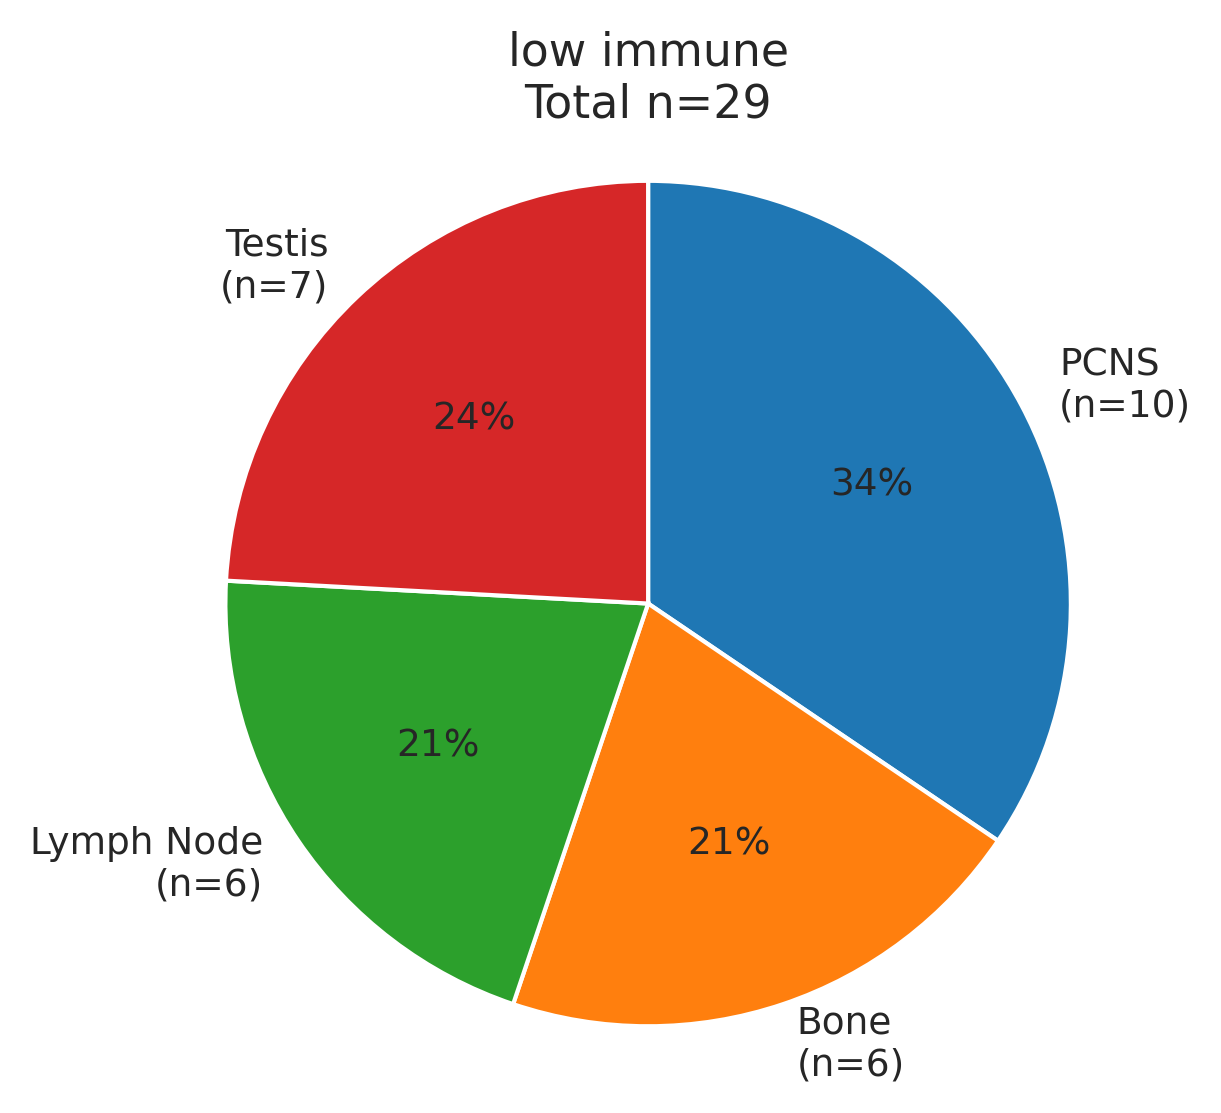

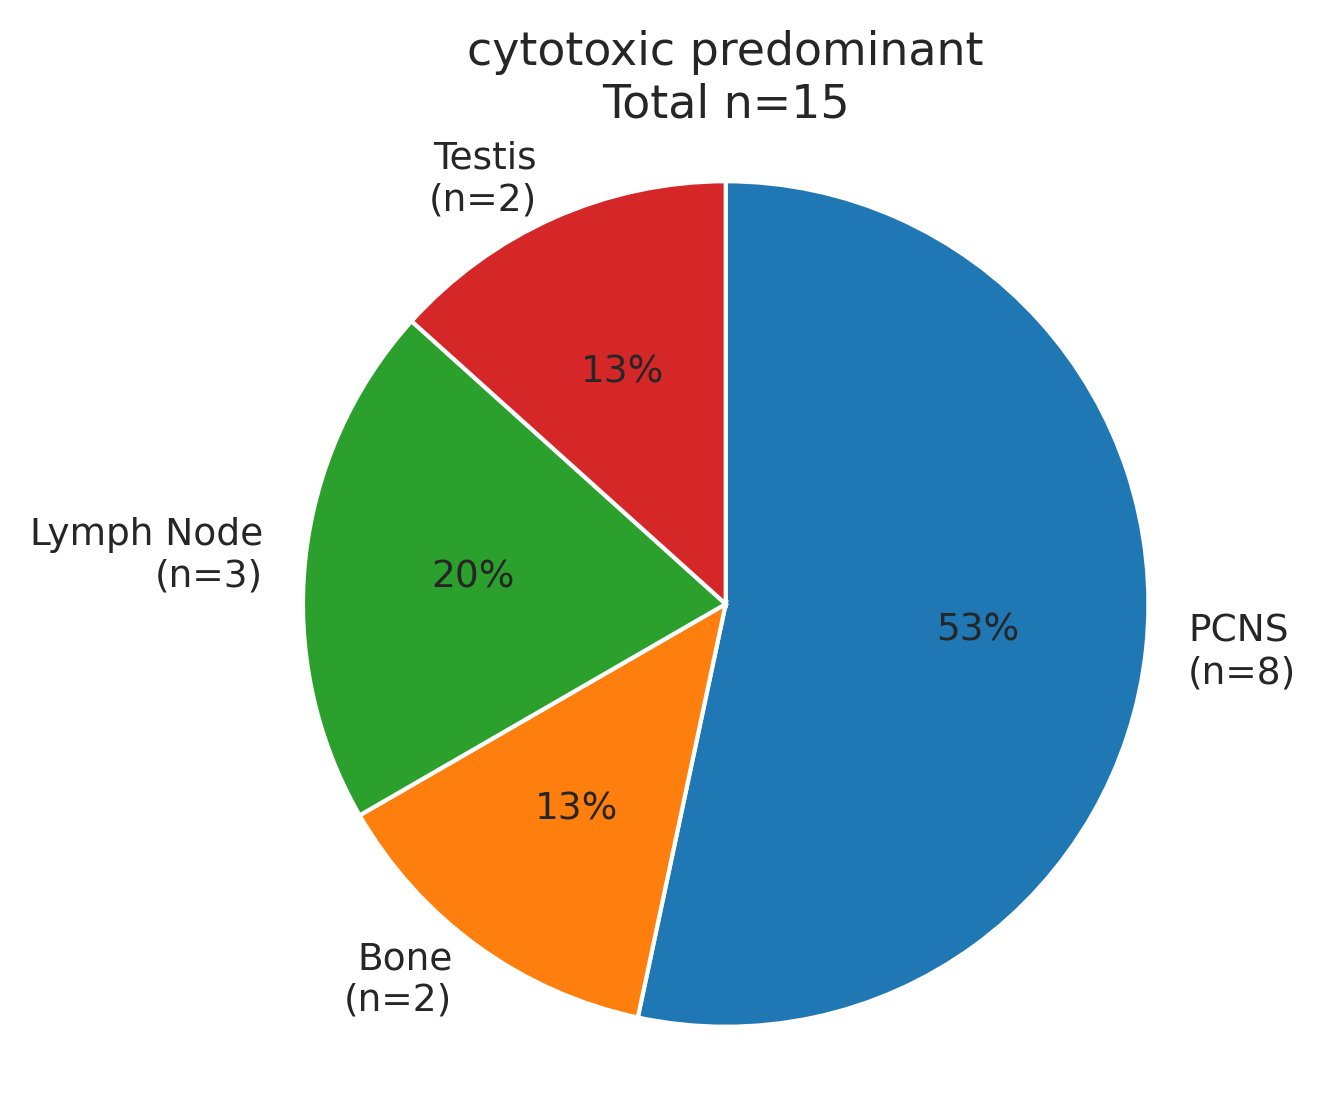

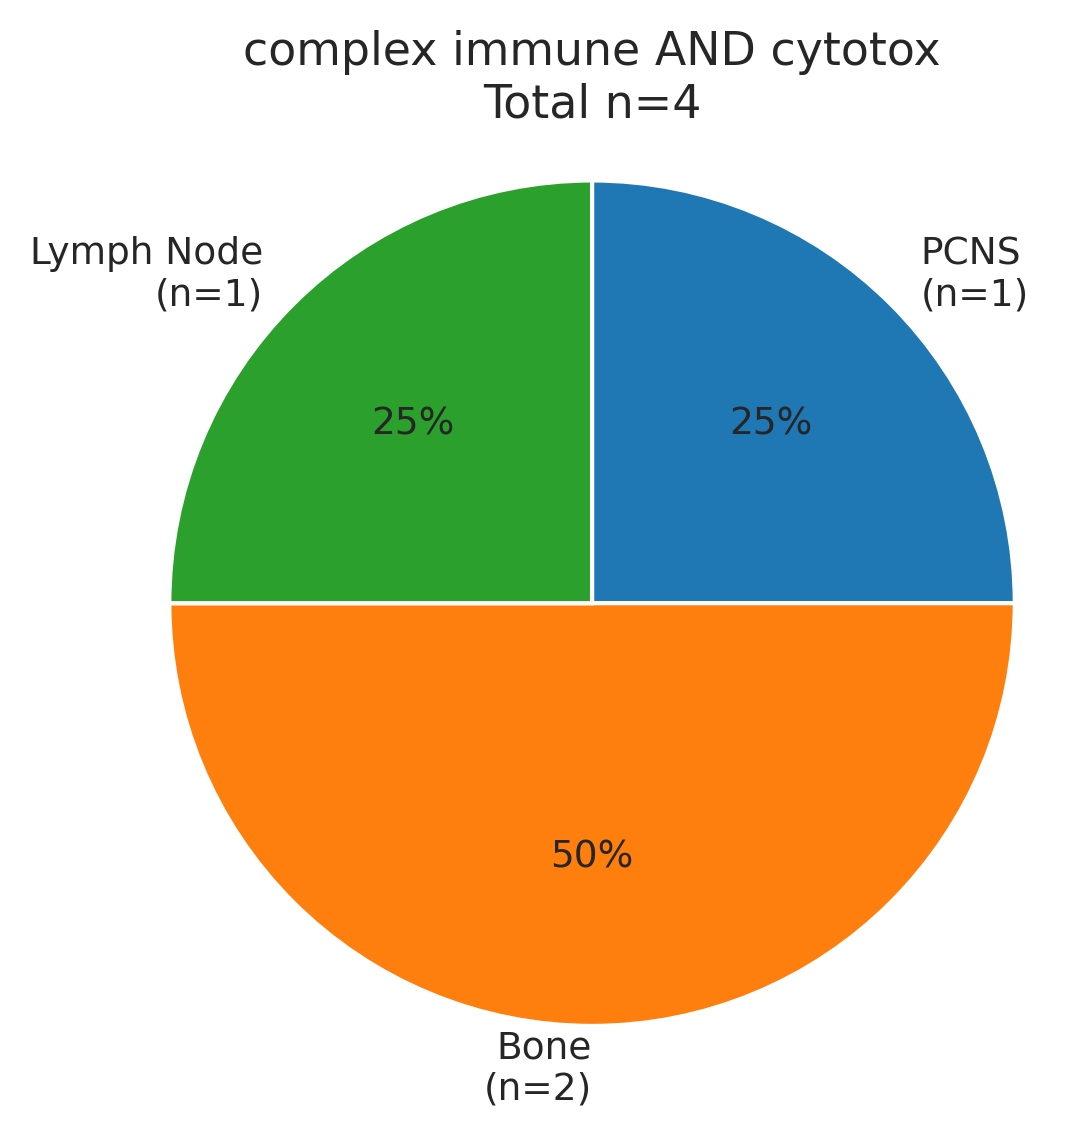

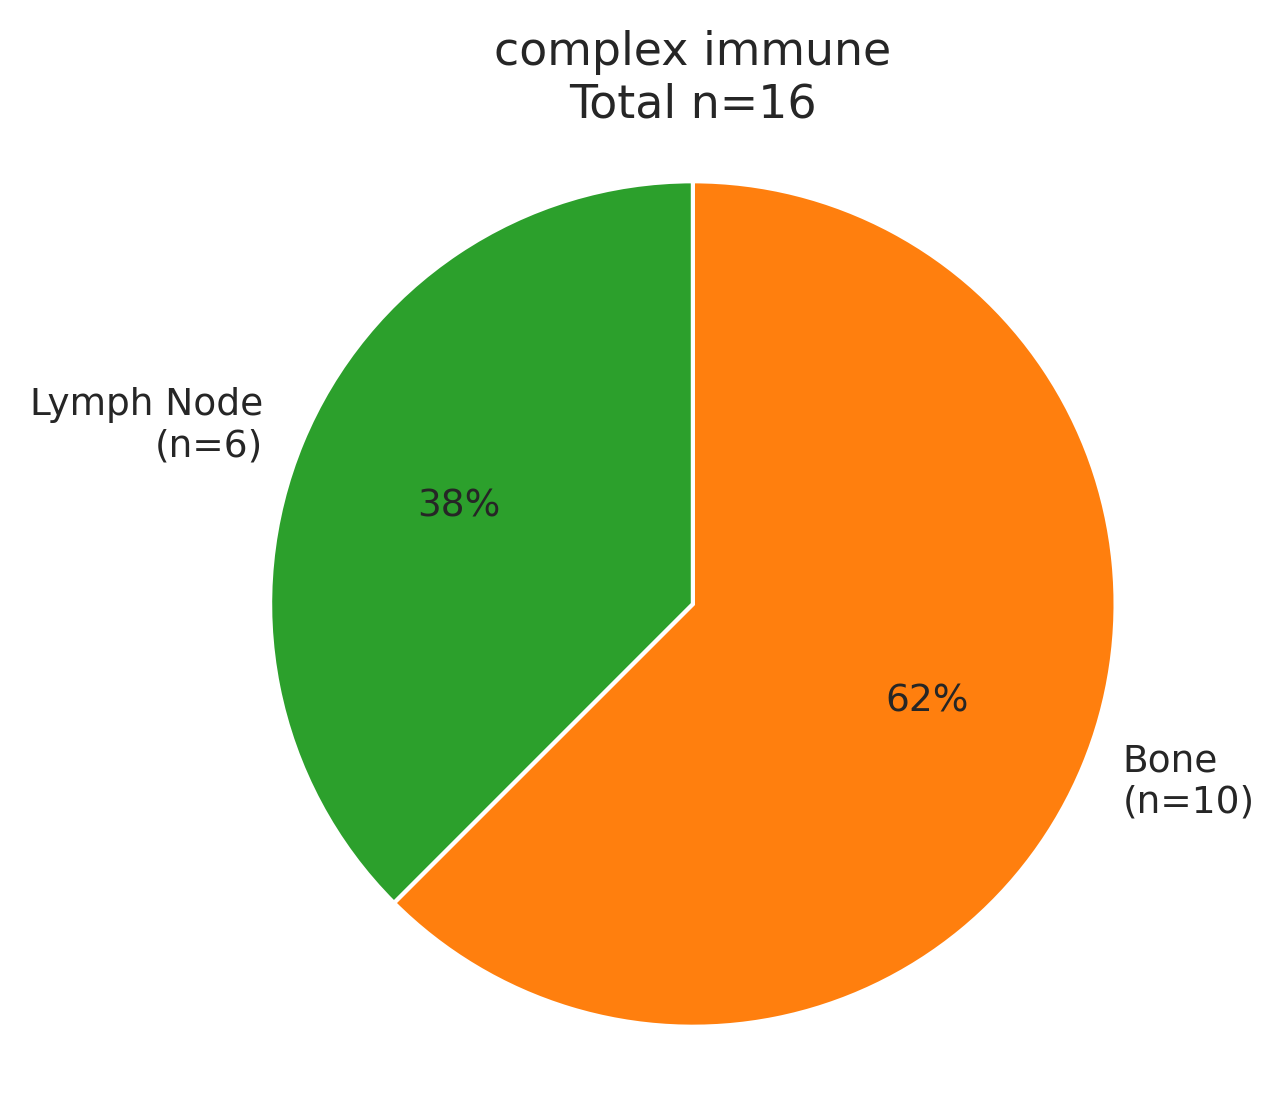

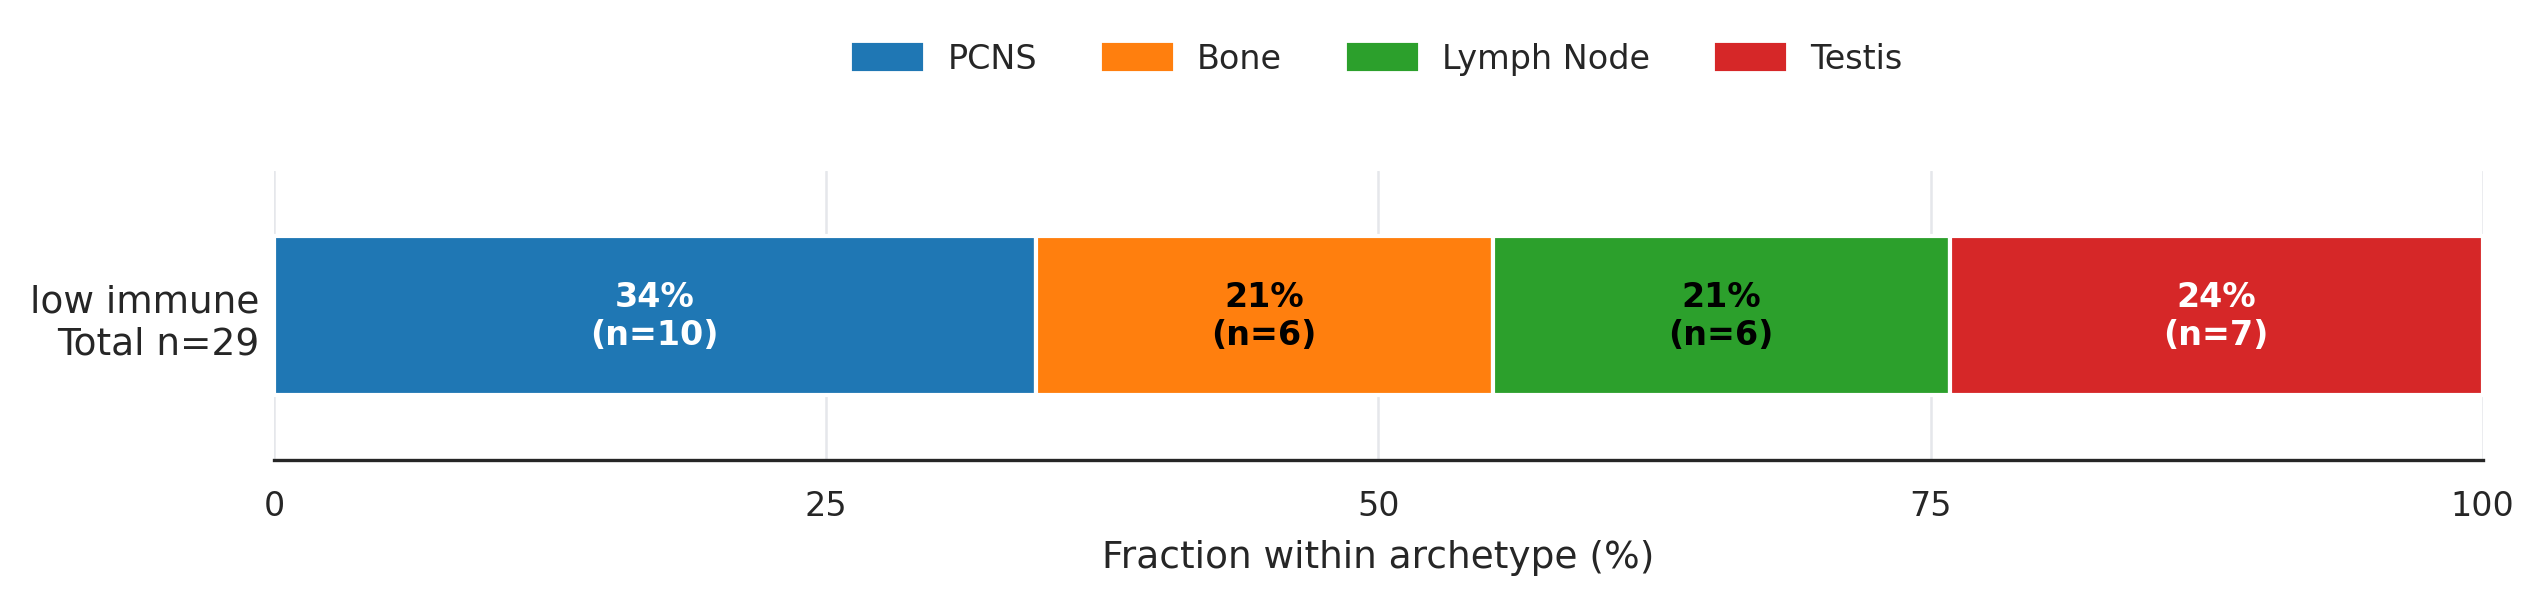

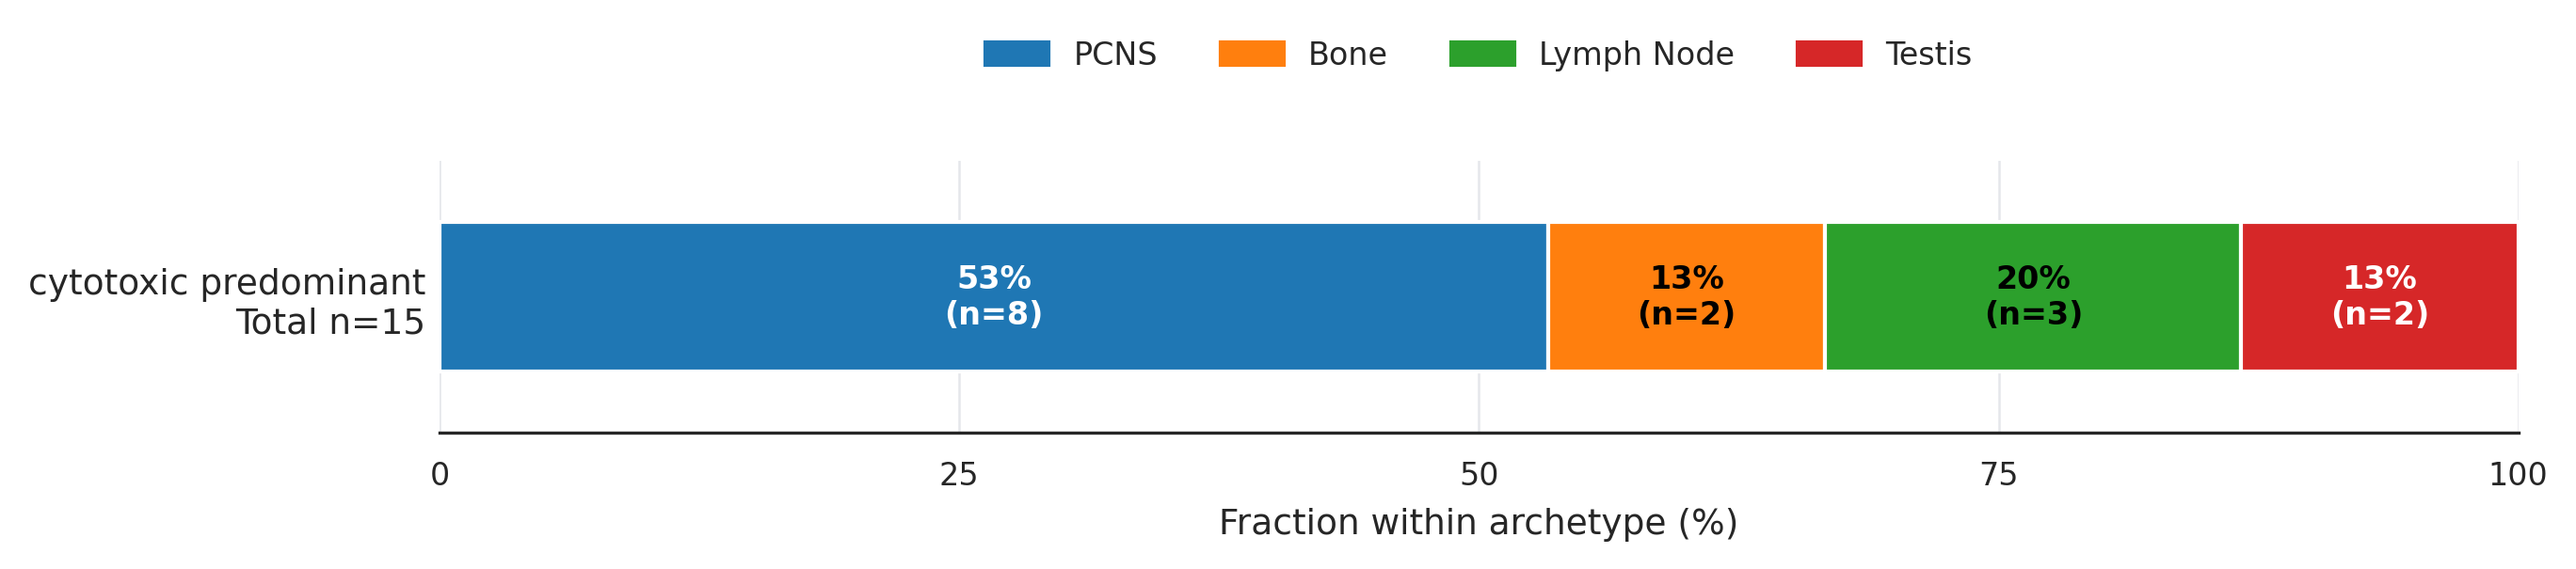

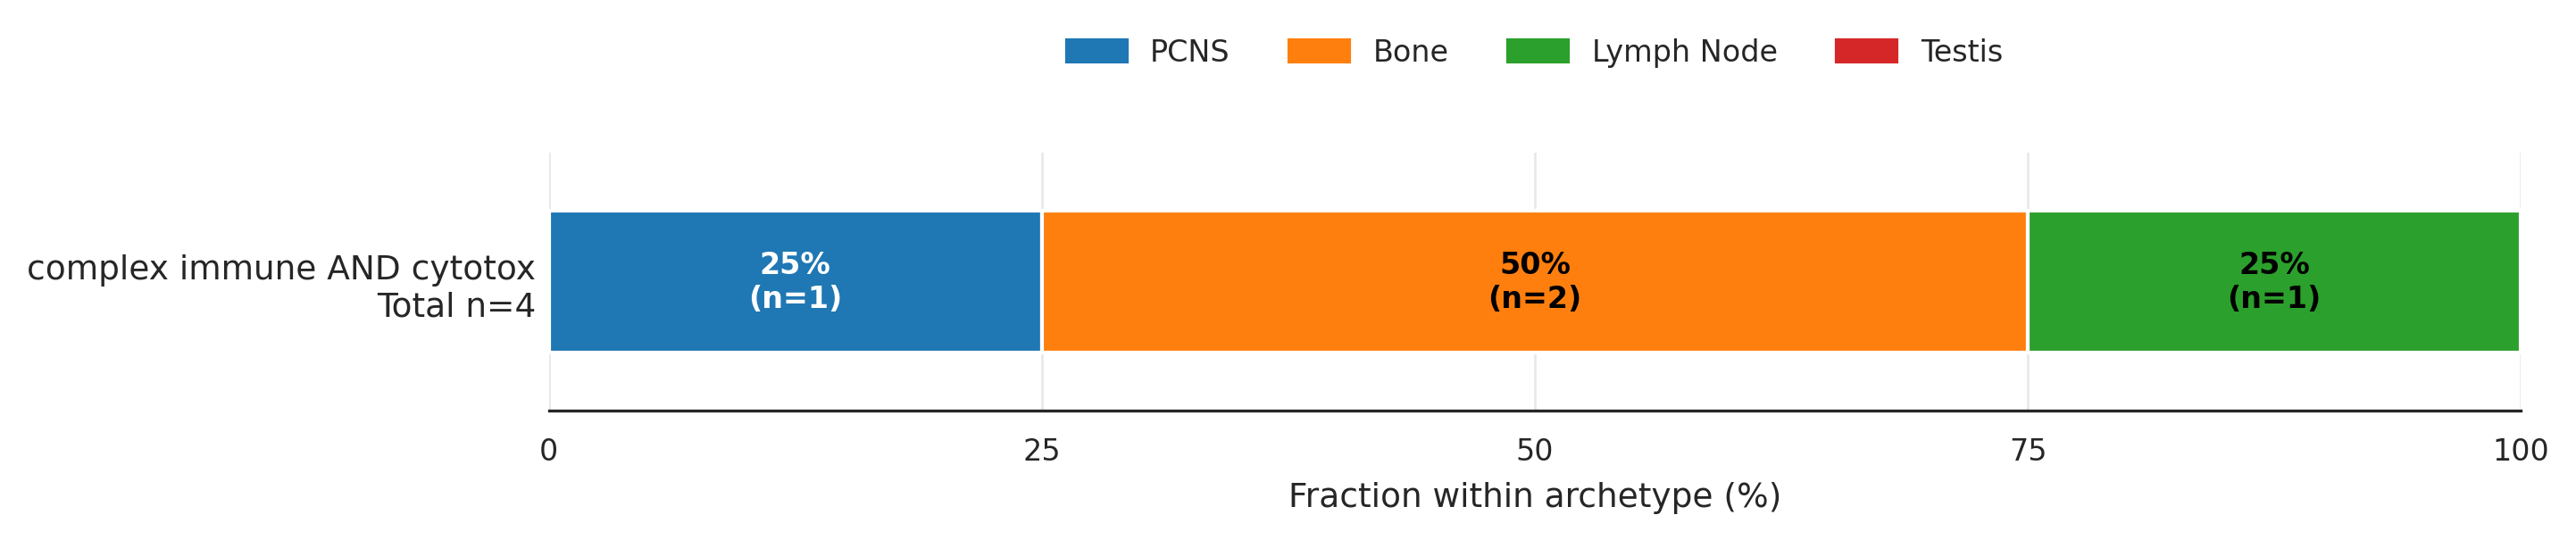

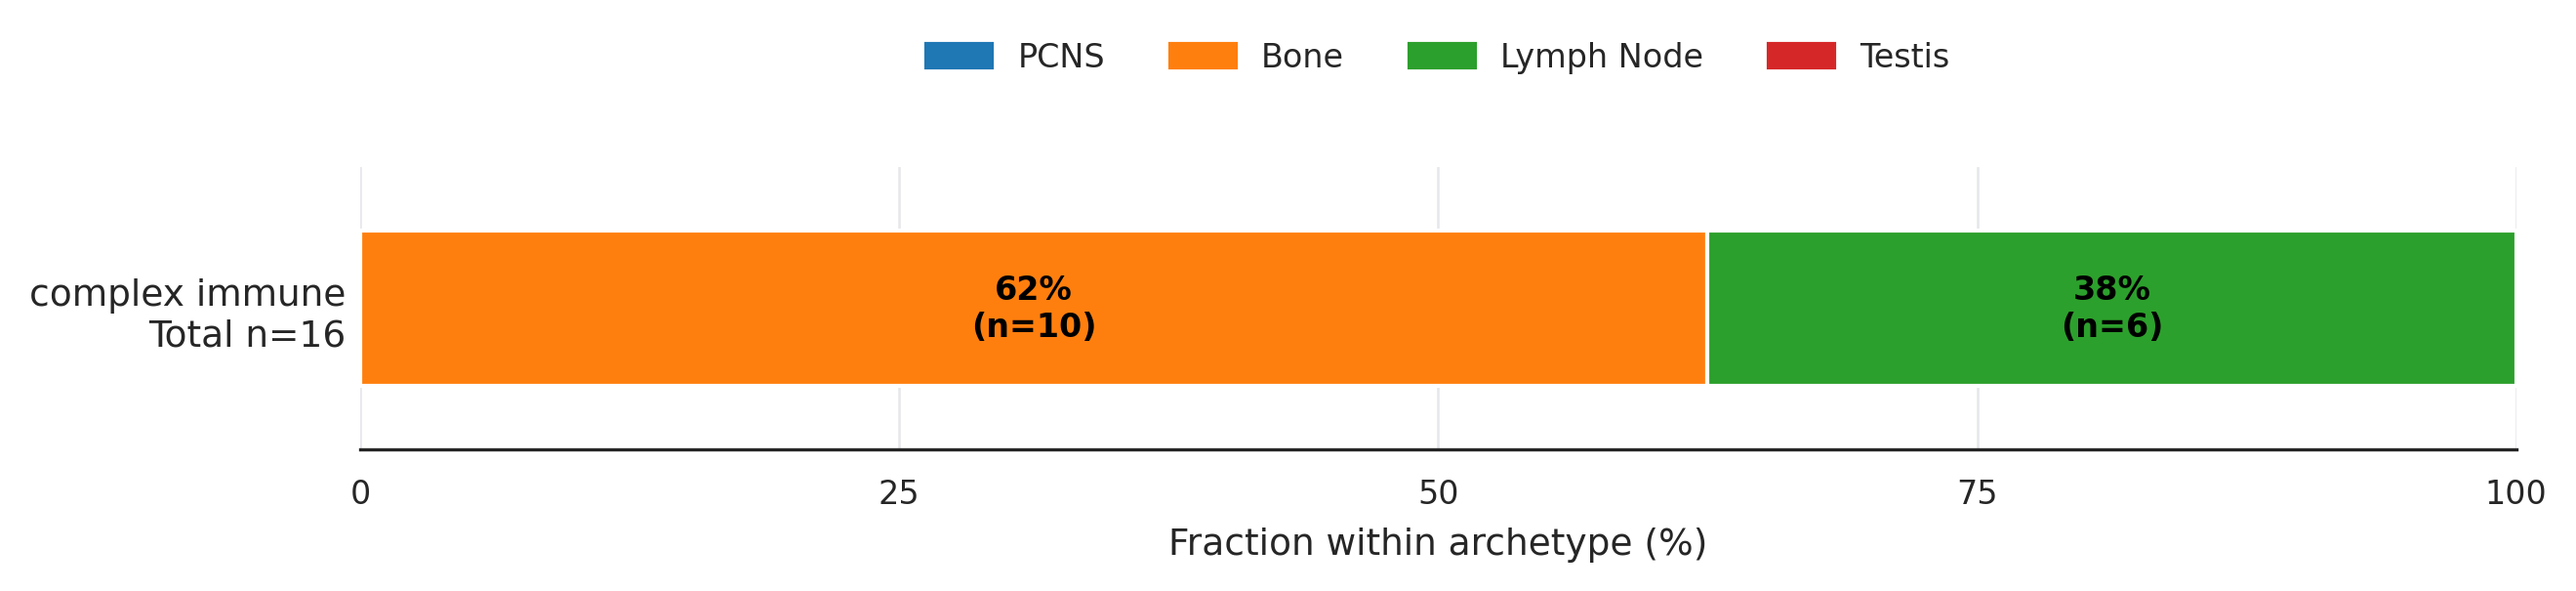

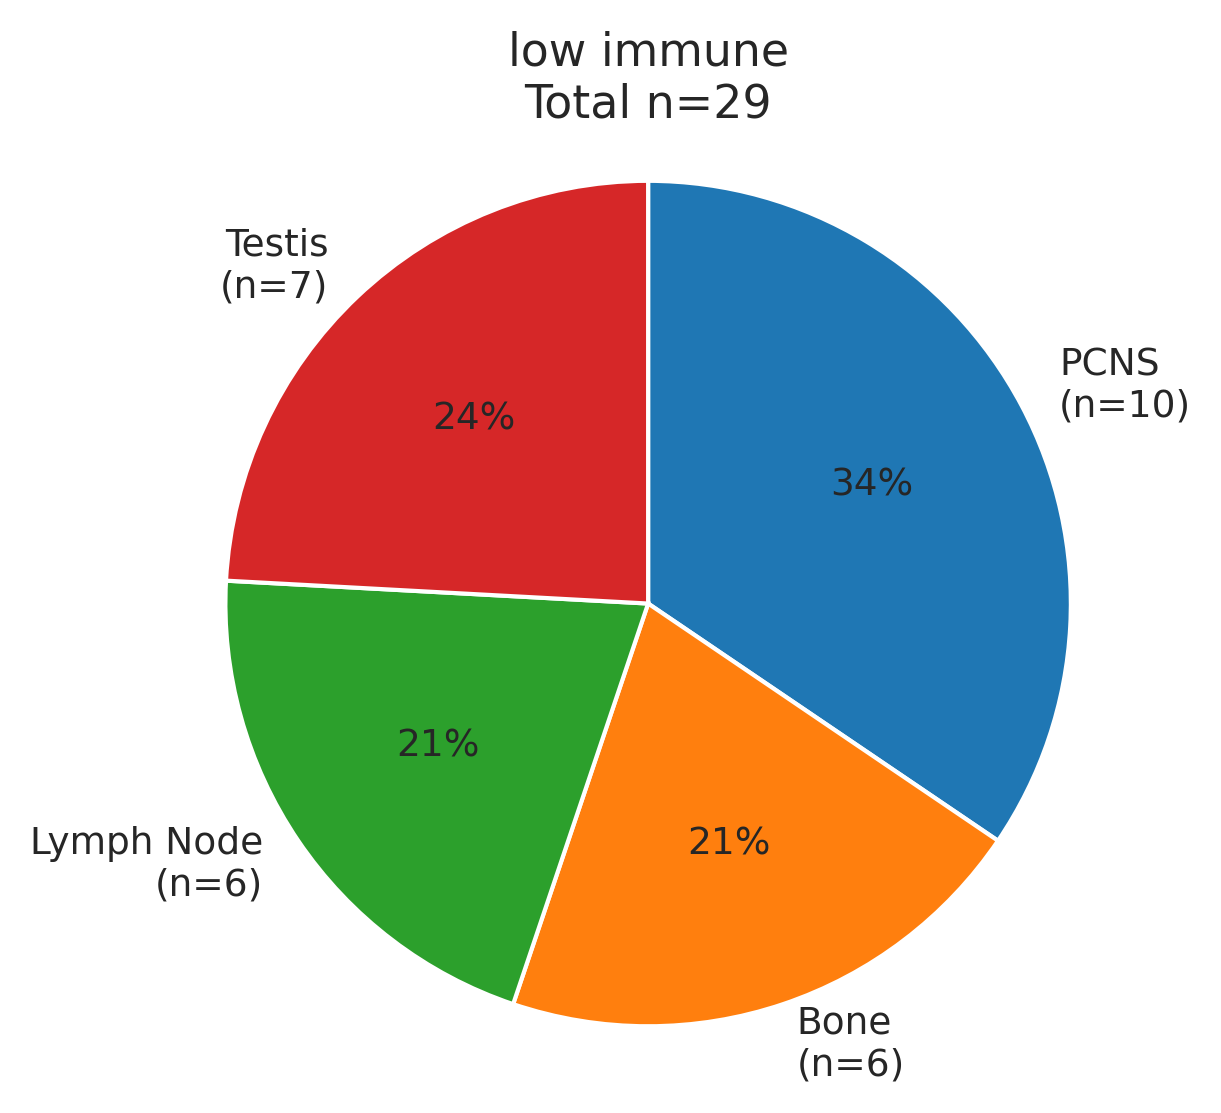

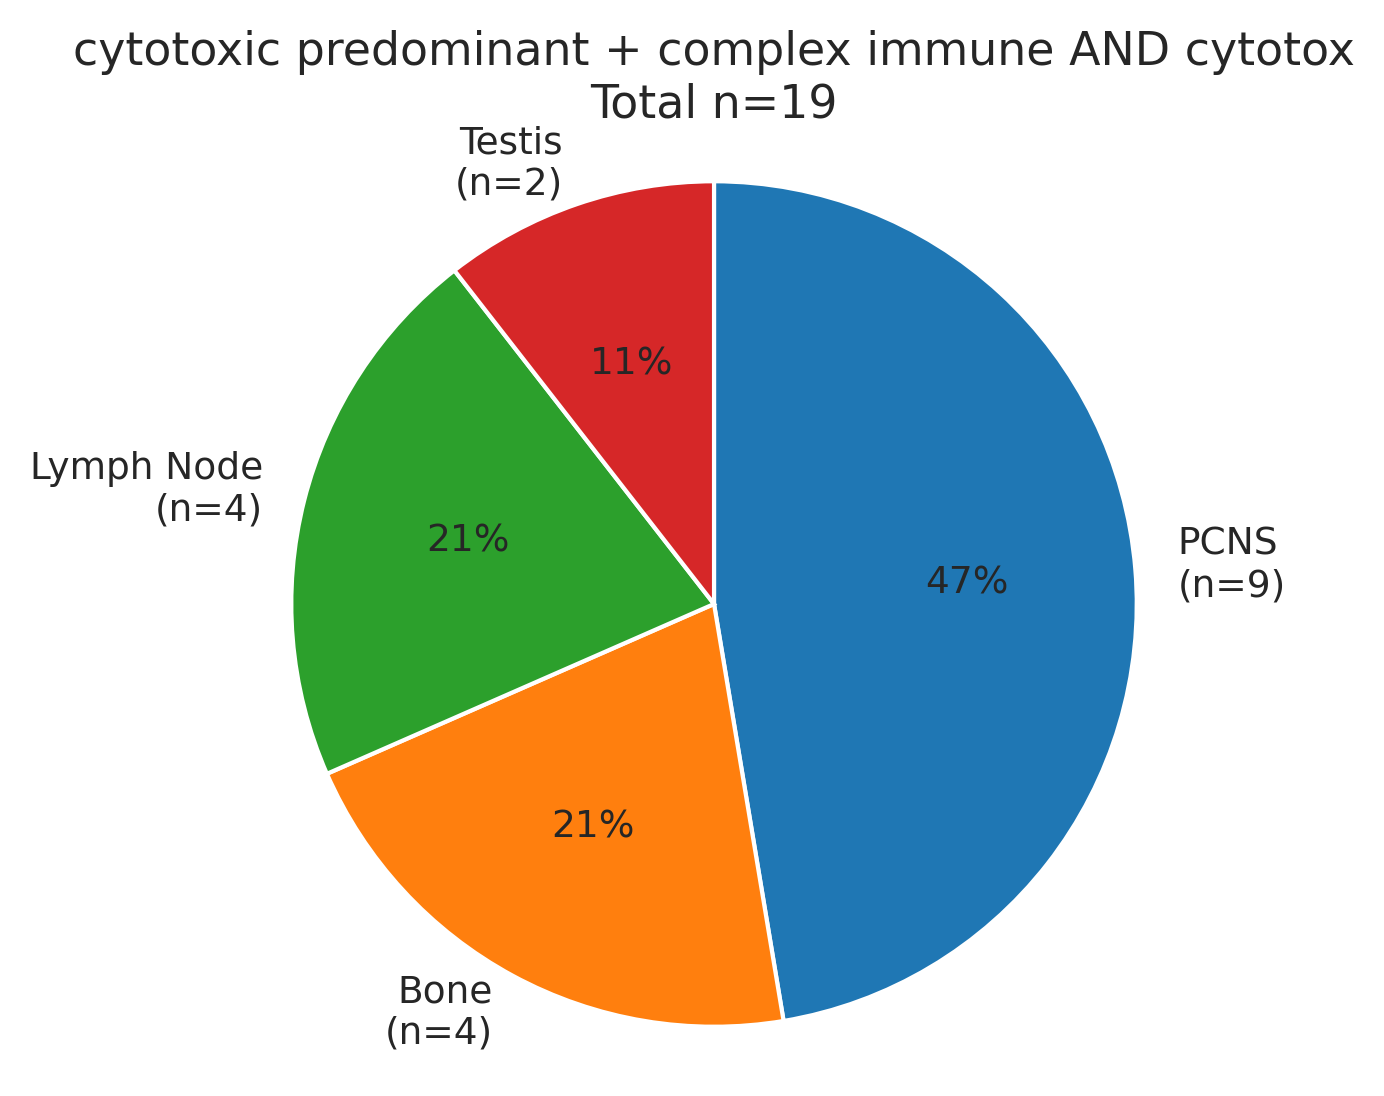

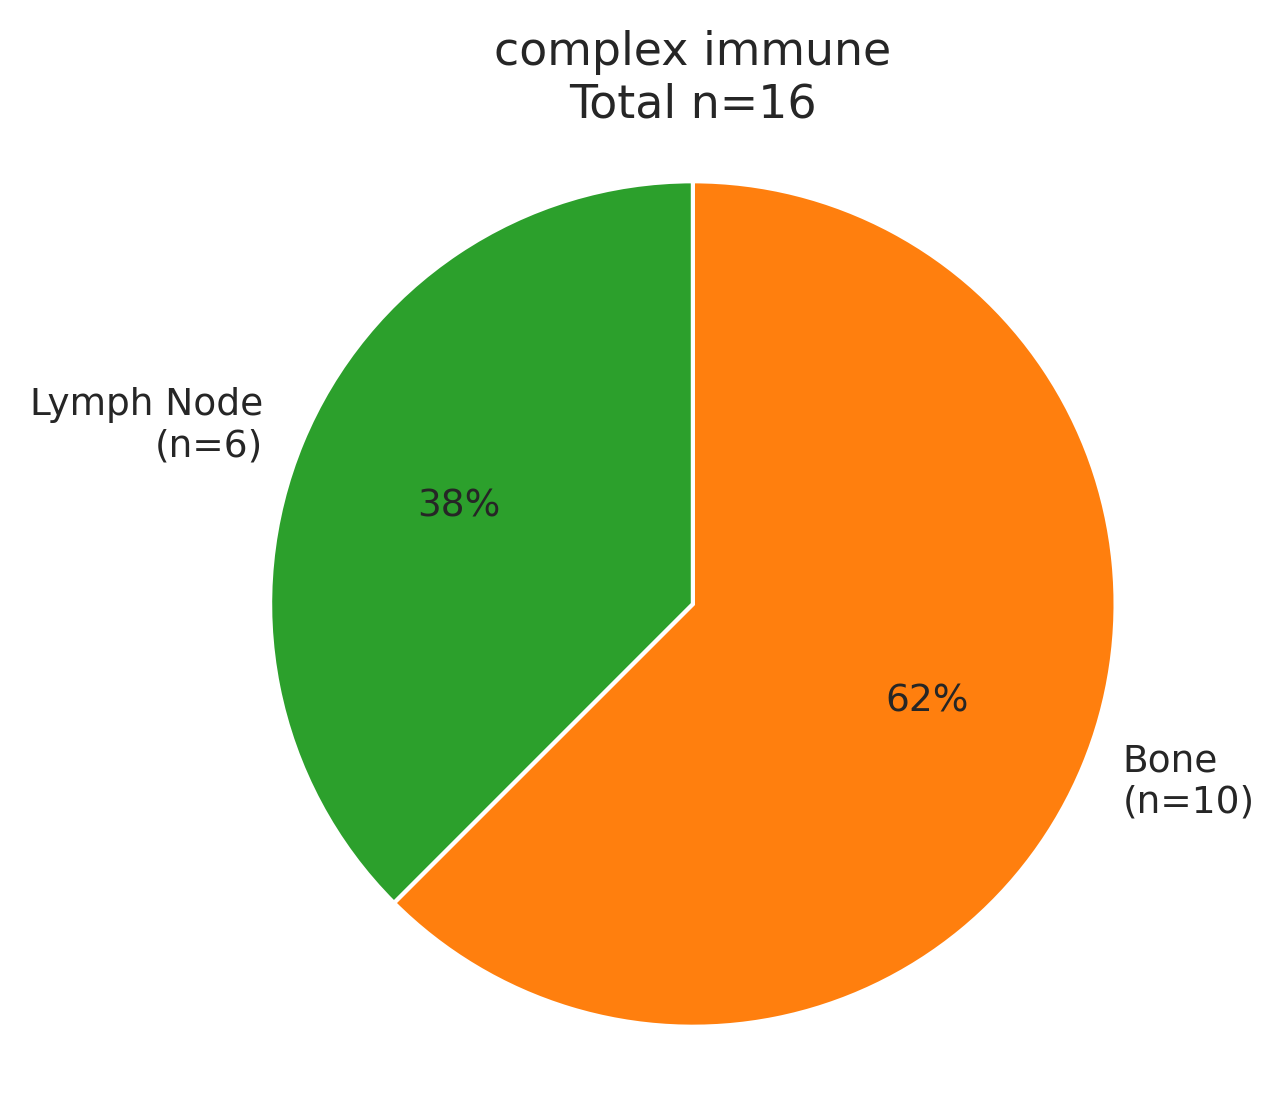

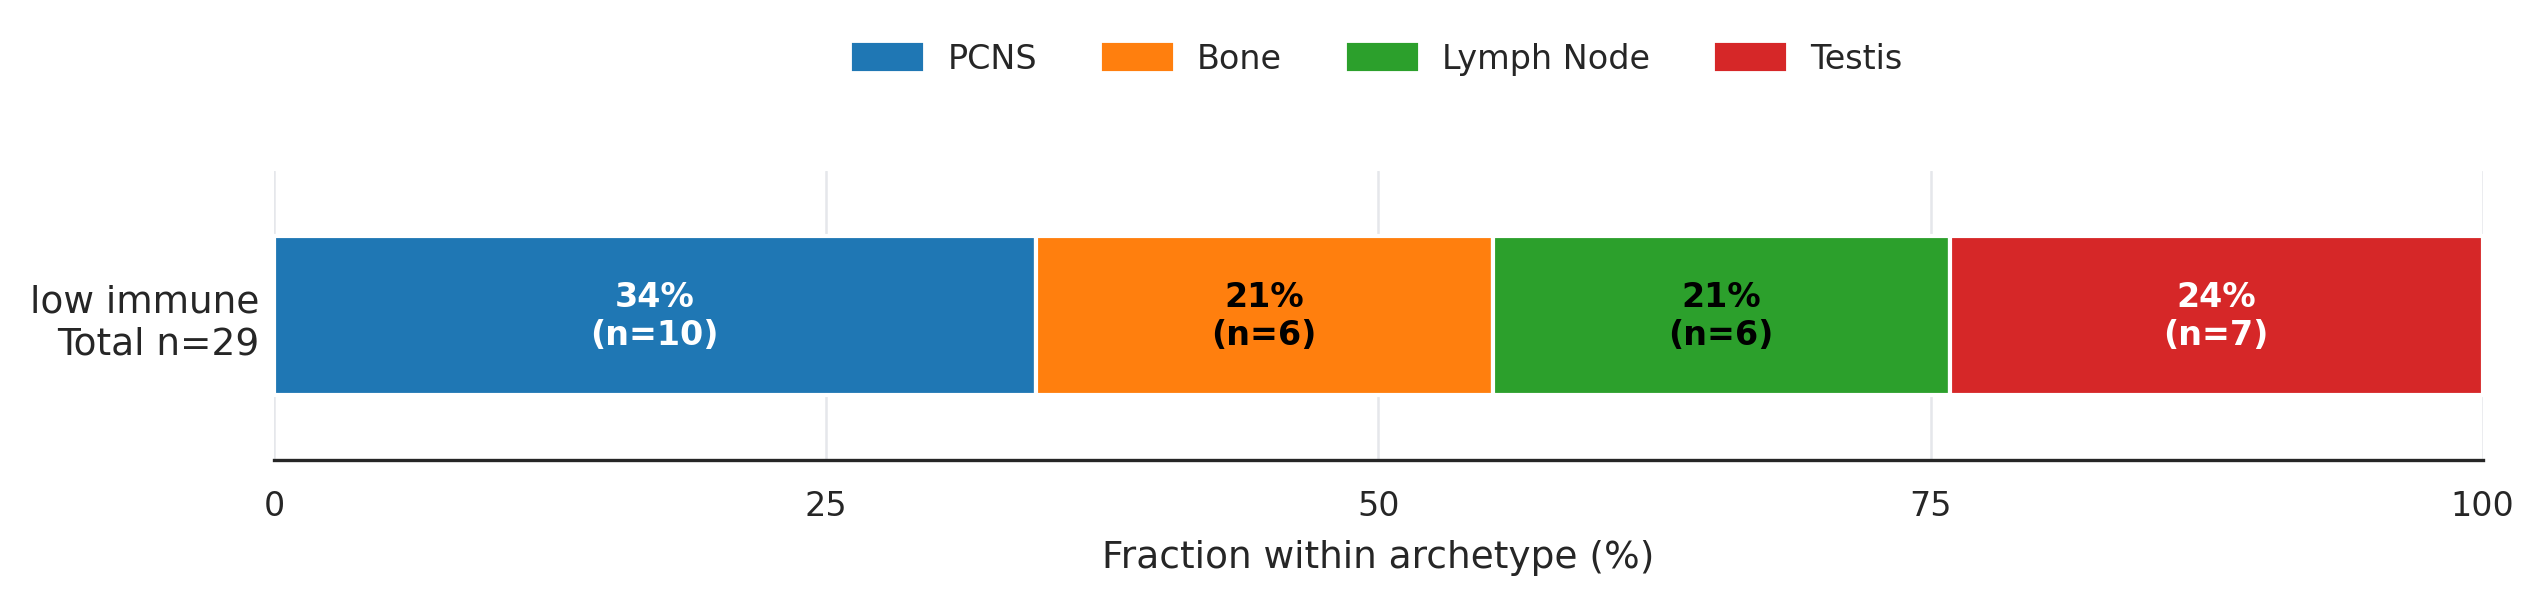

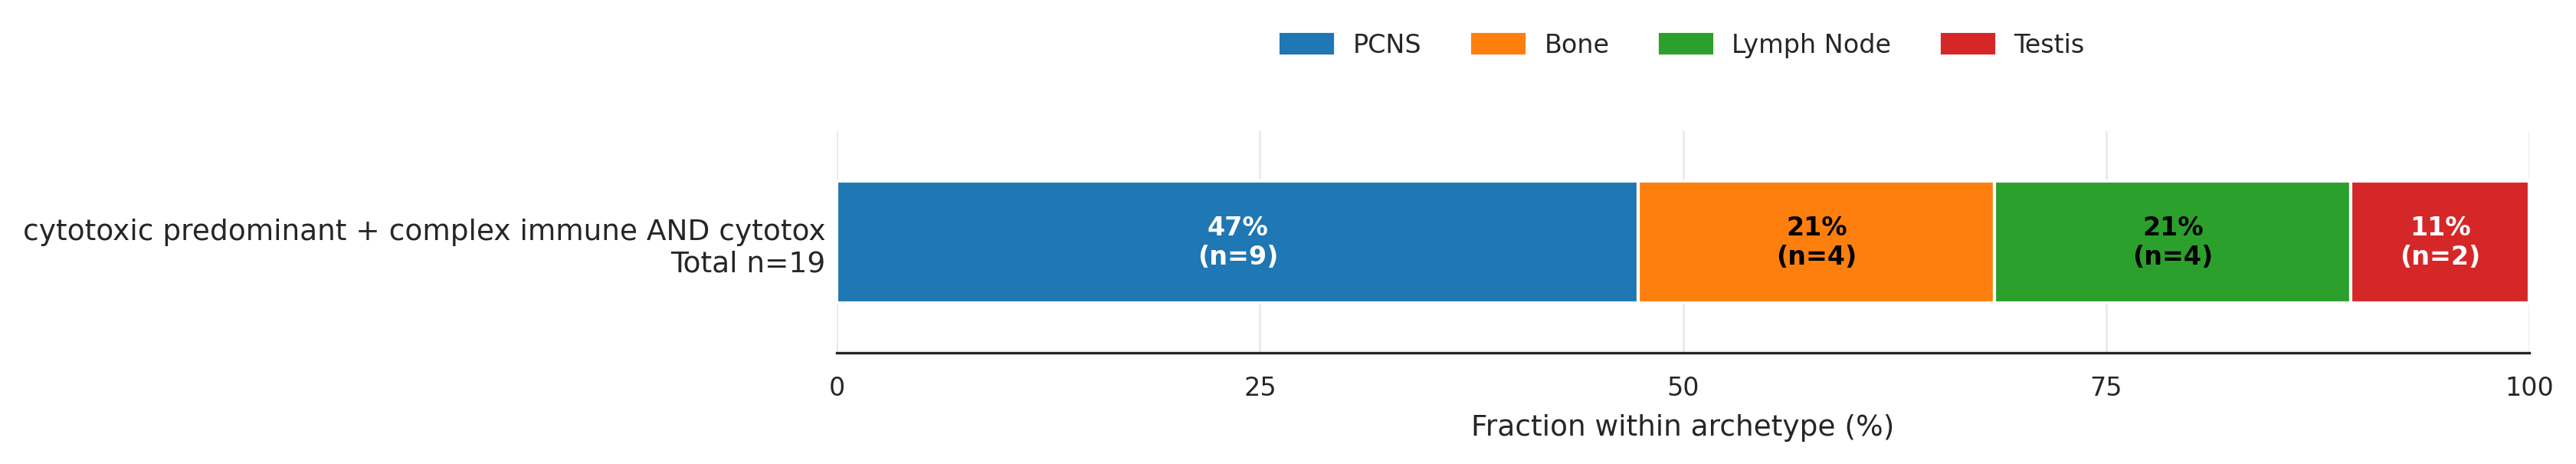

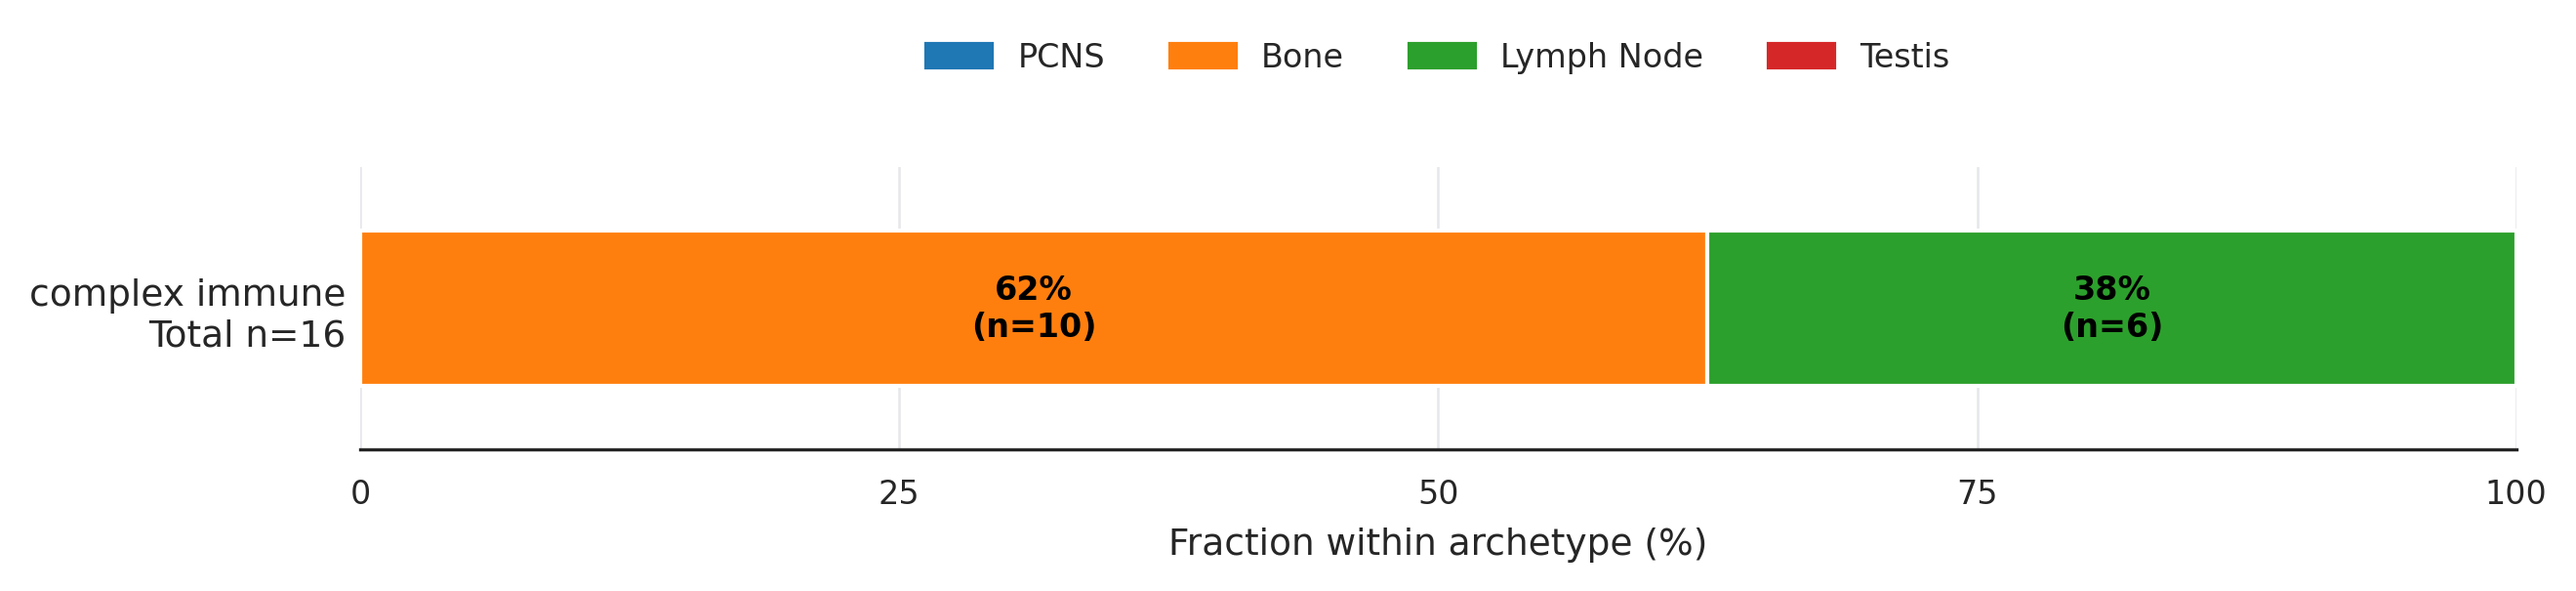

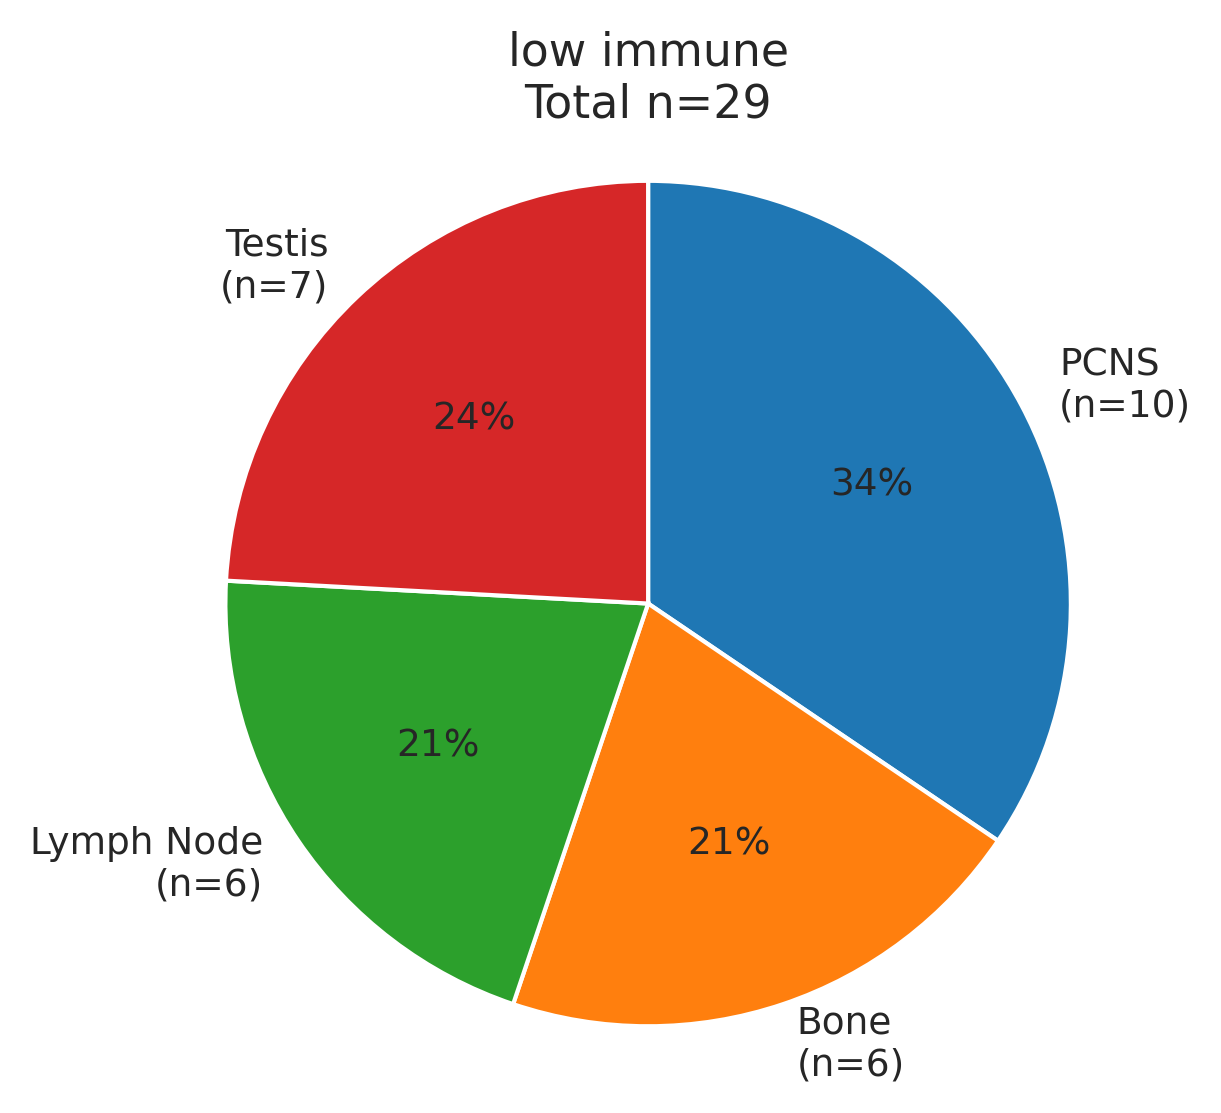

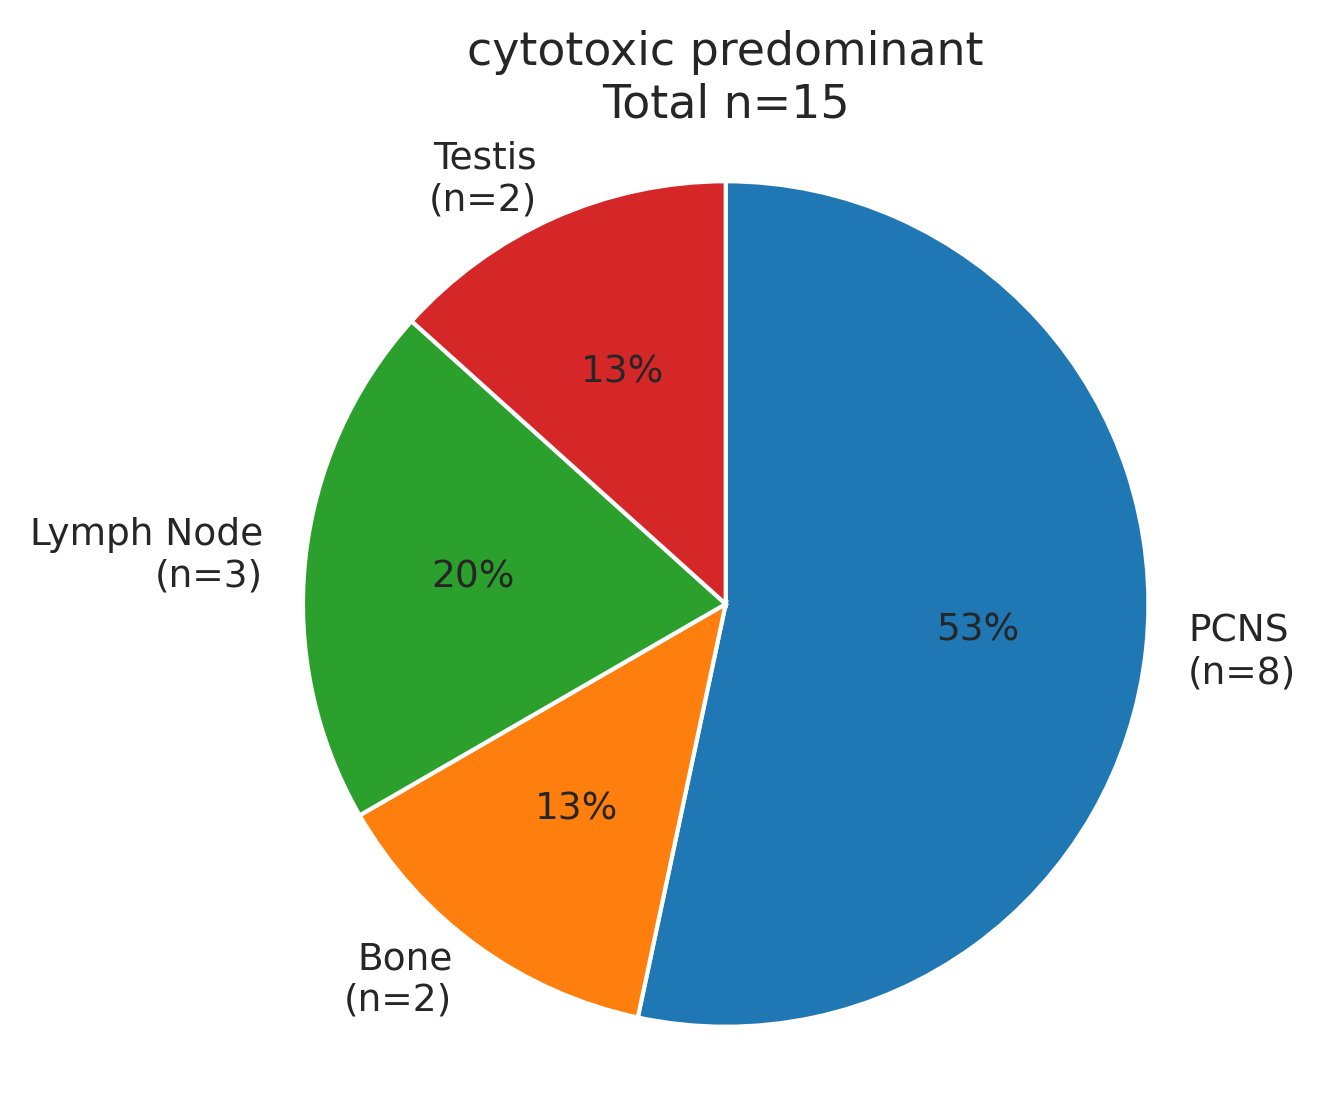

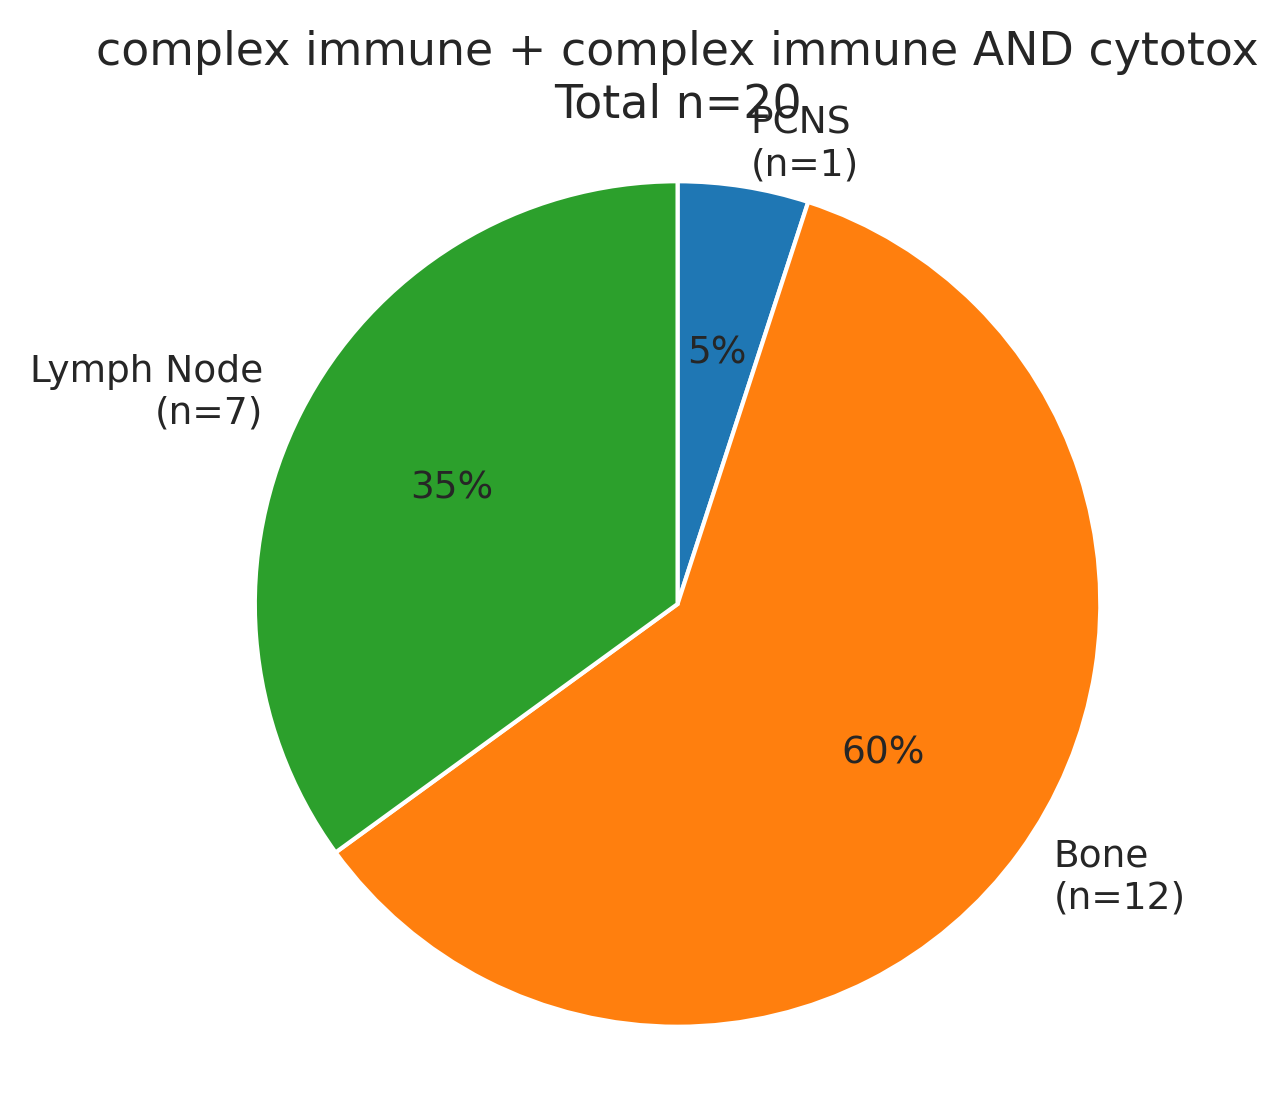

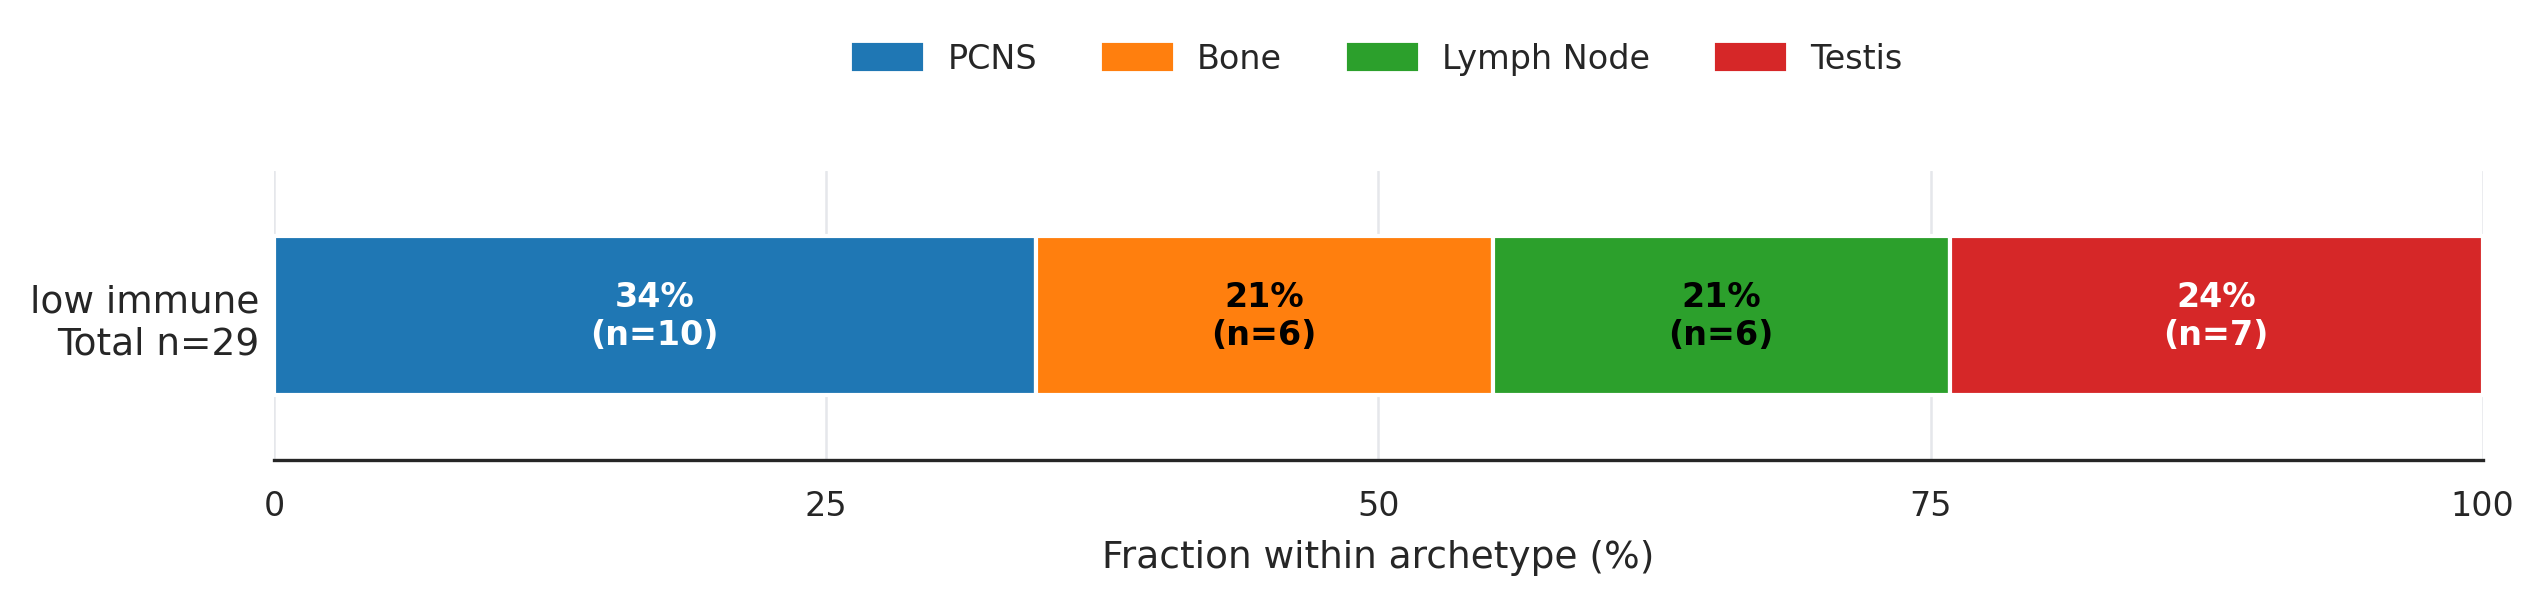

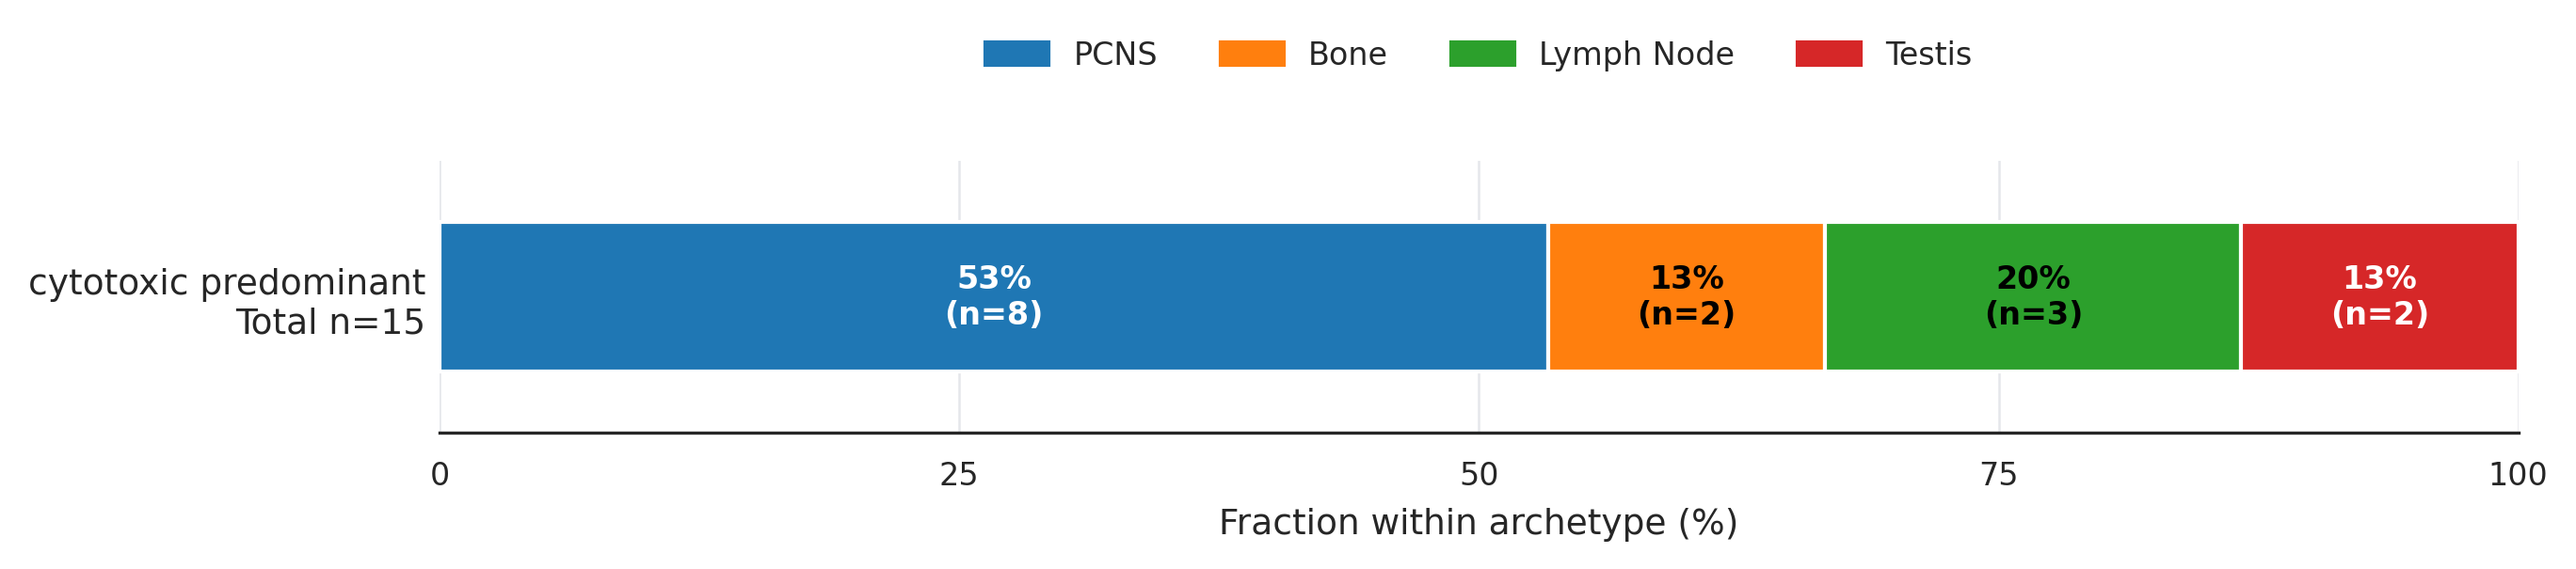

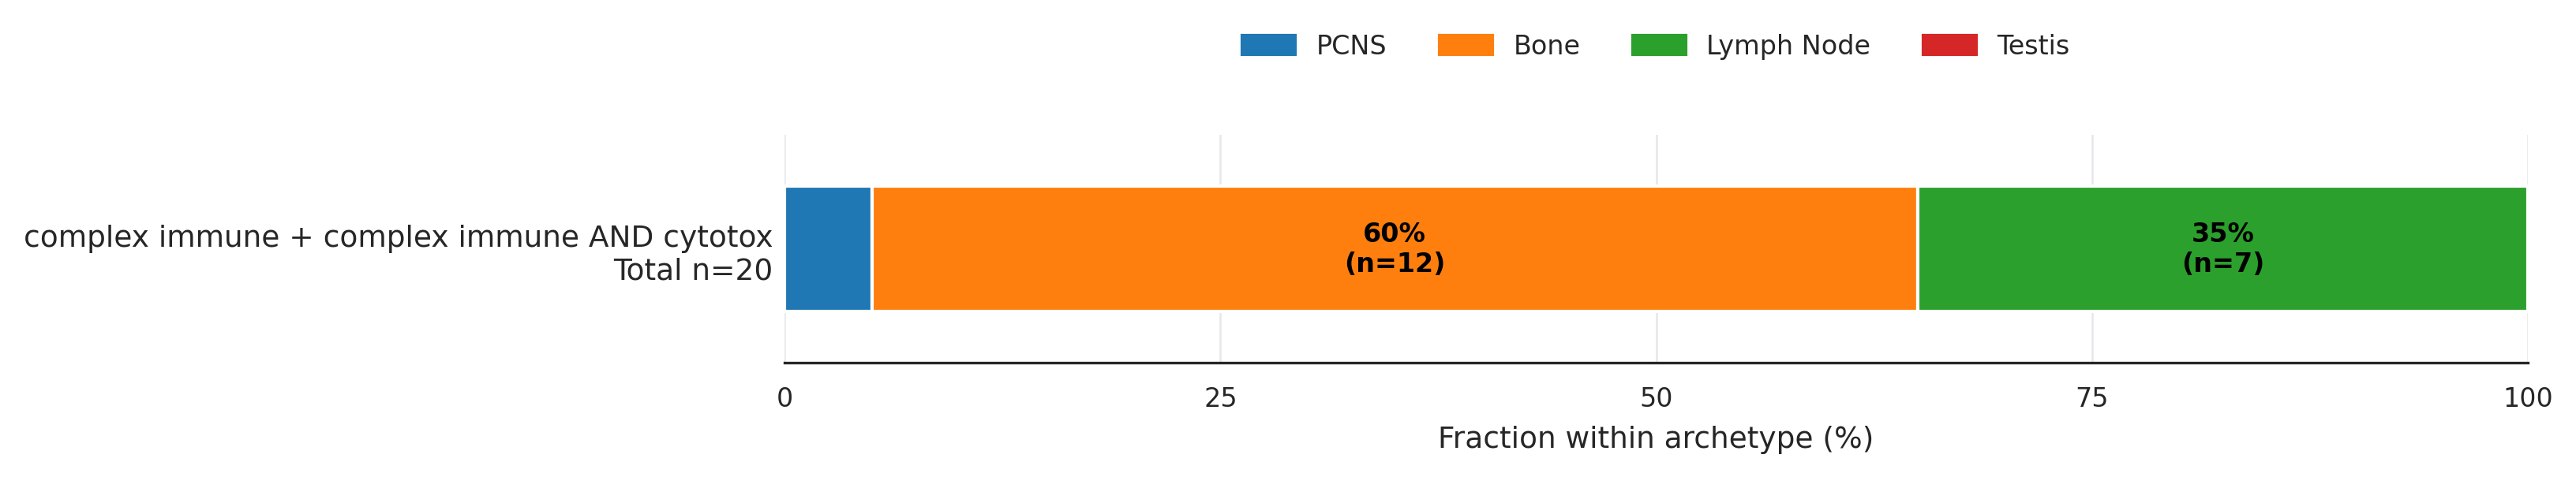

In [16]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# config
# -----------------------------
OUTDIR = Path(FIG_DIR) / ("pies")
OUTDIR.mkdir(exist_ok=True)

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

location_order = ["PCNS", "bone", "nodal", "testis"]
location_display = {
    "PCNS": "PCNS",
    "bone": "Bone",
    "nodal": "Lymph Node",
    "testis": "Testis",
}

location_colors = {
    "bone": "#ff7f0e",
    "nodal": "#2ca02c",
    "PCNS": "#1f77b4",
    "testis": "#d62728",
}

cluster_name_map = {
    1: "low immune",
    2: "cytotoxic predominant",
    3: "complex immune AND cytotox",
    4: "complex immune",
}

# -----------------------------
# metadata
# -----------------------------
meta = pd.DataFrame(adata.uns["case_classifications"]).copy()

if "patient_id" in meta.columns:
    meta = meta.set_index("patient_id")

if "Location" in meta.columns:
    meta["Location"] = meta["Location"].replace({
        "pBONE": "bone",
        "polyOST": "bone",
        "disseminated": "bone",
    })

# -----------------------------
# add raw clusters
# -----------------------------
cluster_dict = adata.uns["abundance_cluster_30_raw"]

meta["cluster_raw"] = meta.index.map(cluster_dict)
meta["cluster_label_raw"] = meta["cluster_raw"].map(cluster_name_map)

# keep only patients with location + cluster
plot_df = meta.dropna(subset=["Location", "cluster_raw"]).copy()
plot_df["cluster_raw"] = plot_df["cluster_raw"].astype(int)

# -----------------------------
# helper function
# -----------------------------
def plot_location_pies_per_cluster(
    df,
    cluster_col,
    cluster_label_map,
    filename_prefix,
):
    clusters = sorted(df[cluster_col].dropna().unique())

    for clust in clusters:
        sub = df[df[cluster_col] == clust].copy()

        counts = (
            sub["Location"]
            .value_counts()
            .reindex(location_order, fill_value=0)
        )

        counts = counts[counts > 0]

        label = cluster_label_map.get(clust, str(clust))

        fig, ax = plt.subplots(figsize=(4, 4))

        ax.pie(
            counts.values,
            labels=[f"{location_display.get(idx, idx)}\n(n={val})" for idx, val in counts.items()],
            colors=[location_colors[idx] for idx in counts.index],
            autopct="%1.0f%%",
            startangle=90,
            counterclock=False,
            wedgeprops={"linewidth": 1, "edgecolor": "white"},
            textprops={"fontsize": 9},
        )

        ax.set_title(f"{label}\nTotal n={counts.sum()}", fontsize=11)
        ax.axis("equal")

        safe_label = str(label).replace(" ", "_").replace("/", "_")
        fig.savefig(
            OUTDIR / f"{filename_prefix}_cluster_{clust}_{safe_label}.pdf",
            bbox_inches="tight",
        )
        fig.savefig(
            OUTDIR / f"{filename_prefix}_cluster_{clust}_{safe_label}.svg",
            format="svg",
            bbox_inches="tight",
        )
        fig.savefig(
            OUTDIR / f"{filename_prefix}_cluster_{clust}_{safe_label}.png",
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()
        plt.close(fig)


def plot_location_stacked_bars_per_cluster(
    df,
    cluster_col,
    cluster_label_map,
    filename_prefix,
    *,
    width=9.5,
):
    clusters = sorted(df[cluster_col].dropna().unique())

    for clust in clusters:
        sub = df[df[cluster_col] == clust].copy()
        counts = (
            sub["Location"]
            .value_counts()
            .reindex(location_order, fill_value=0)
        )
        total = int(counts.sum())
        if total == 0:
            continue

        label = cluster_label_map.get(clust, str(clust))
        props = counts / total

        fig, ax = plt.subplots(figsize=(width, 1.25))
        left = 0.0
        for loc in location_order:
            prop = float(props.loc[loc])
            count = int(counts.loc[loc])
            if count == 0:
                continue
            ax.barh(
                [0],
                [prop],
                left=left,
                height=0.55,
                color=location_colors[loc],
                edgecolor="white",
                linewidth=1.0,
            )
            if prop >= 0.08:
                ax.text(
                    left + prop / 2,
                    0,
                    f"{prop:.0%}\n(n={count})",
                    ha="center",
                    va="center",
                    fontsize=8,
                    fontweight="bold",
                    color="white" if loc in {"PCNS", "testis"} else "black",
                )
            left += prop

        ax.set_xlim(0, 1)
        ax.set_ylim(-0.5, 0.5)
        ax.set_yticks([0])
        ax.set_yticklabels([f"{label}\nTotal n={total}"], fontsize=9)
        ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
        ax.set_xticklabels(["0", "25", "50", "75", "100"], fontsize=8)
        ax.set_xlabel("Fraction within archetype (%)", fontsize=9)
        ax.grid(axis="x", color="#e5e7eb", linewidth=0.6)
        ax.set_axisbelow(True)
        ax.spines[["top", "right", "left"]].set_visible(False)
        ax.tick_params(axis="y", length=0)

        handles = [
            plt.Rectangle((0, 0), 1, 1, color=location_colors[loc])
            for loc in location_order
        ]
        labels = [location_display[loc] for loc in location_order]
        ax.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.55),
            ncol=len(location_order),
            frameon=False,
            fontsize=8,
        )

        safe_label = str(label).replace(" ", "_").replace("/", "_")
        fig.savefig(
            OUTDIR / f"{filename_prefix}_cluster_{clust}_{safe_label}_horizontal_stacked_bar.pdf",
            bbox_inches="tight",
        )
        fig.savefig(
            OUTDIR / f"{filename_prefix}_cluster_{clust}_{safe_label}_horizontal_stacked_bar.svg",
            format="svg",
            bbox_inches="tight",
        )
        fig.savefig(
            OUTDIR / f"{filename_prefix}_cluster_{clust}_{safe_label}_horizontal_stacked_bar.png",
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()
        plt.close(fig)


# -----------------------------
# 1) raw 4-cluster version
# -----------------------------
plot_location_pies_per_cluster(
    plot_df,
    cluster_col="cluster_raw",
    cluster_label_map=cluster_name_map,
    filename_prefix="raw_4cluster",
)
plot_location_stacked_bars_per_cluster(
    plot_df,
    cluster_col="cluster_raw",
    cluster_label_map=cluster_name_map,
    filename_prefix="raw_4cluster",
)

# -----------------------------
# 2) fuse cluster 3 into cluster 2
# -----------------------------
plot_df["cluster_3_to_2"] = plot_df["cluster_raw"].replace({3: 2})

cluster_name_map_3_to_2 = {
    1: "low immune",
    2: "cytotoxic predominant + complex immune AND cytotox",
    4: "complex immune",
}

plot_location_pies_per_cluster(
    plot_df,
    cluster_col="cluster_3_to_2",
    cluster_label_map=cluster_name_map_3_to_2,
    filename_prefix="fused_3_to_2",
)
plot_location_stacked_bars_per_cluster(
    plot_df,
    cluster_col="cluster_3_to_2",
    cluster_label_map=cluster_name_map_3_to_2,
    filename_prefix="fused_3_to_2",
)

# -----------------------------
# 3) fuse cluster 3 into cluster 4
# -----------------------------
plot_df["cluster_3_to_4"] = plot_df["cluster_raw"].replace({3: 4})

cluster_name_map_3_to_4 = {
    1: "low immune",
    2: "cytotoxic predominant",
    4: "complex immune + complex immune AND cytotox",
}

plot_location_pies_per_cluster(
    plot_df,
    cluster_col="cluster_3_to_4",
    cluster_label_map=cluster_name_map_3_to_4,
    filename_prefix="fused_3_to_4",
)
plot_location_stacked_bars_per_cluster(
    plot_df,
    cluster_col="cluster_3_to_4",
    cluster_label_map=cluster_name_map_3_to_4,
    filename_prefix="fused_3_to_4",
)

## Fig 2F / 2G — KM by archetype (+ Supp PFS) (`abundance_cluster_30`)

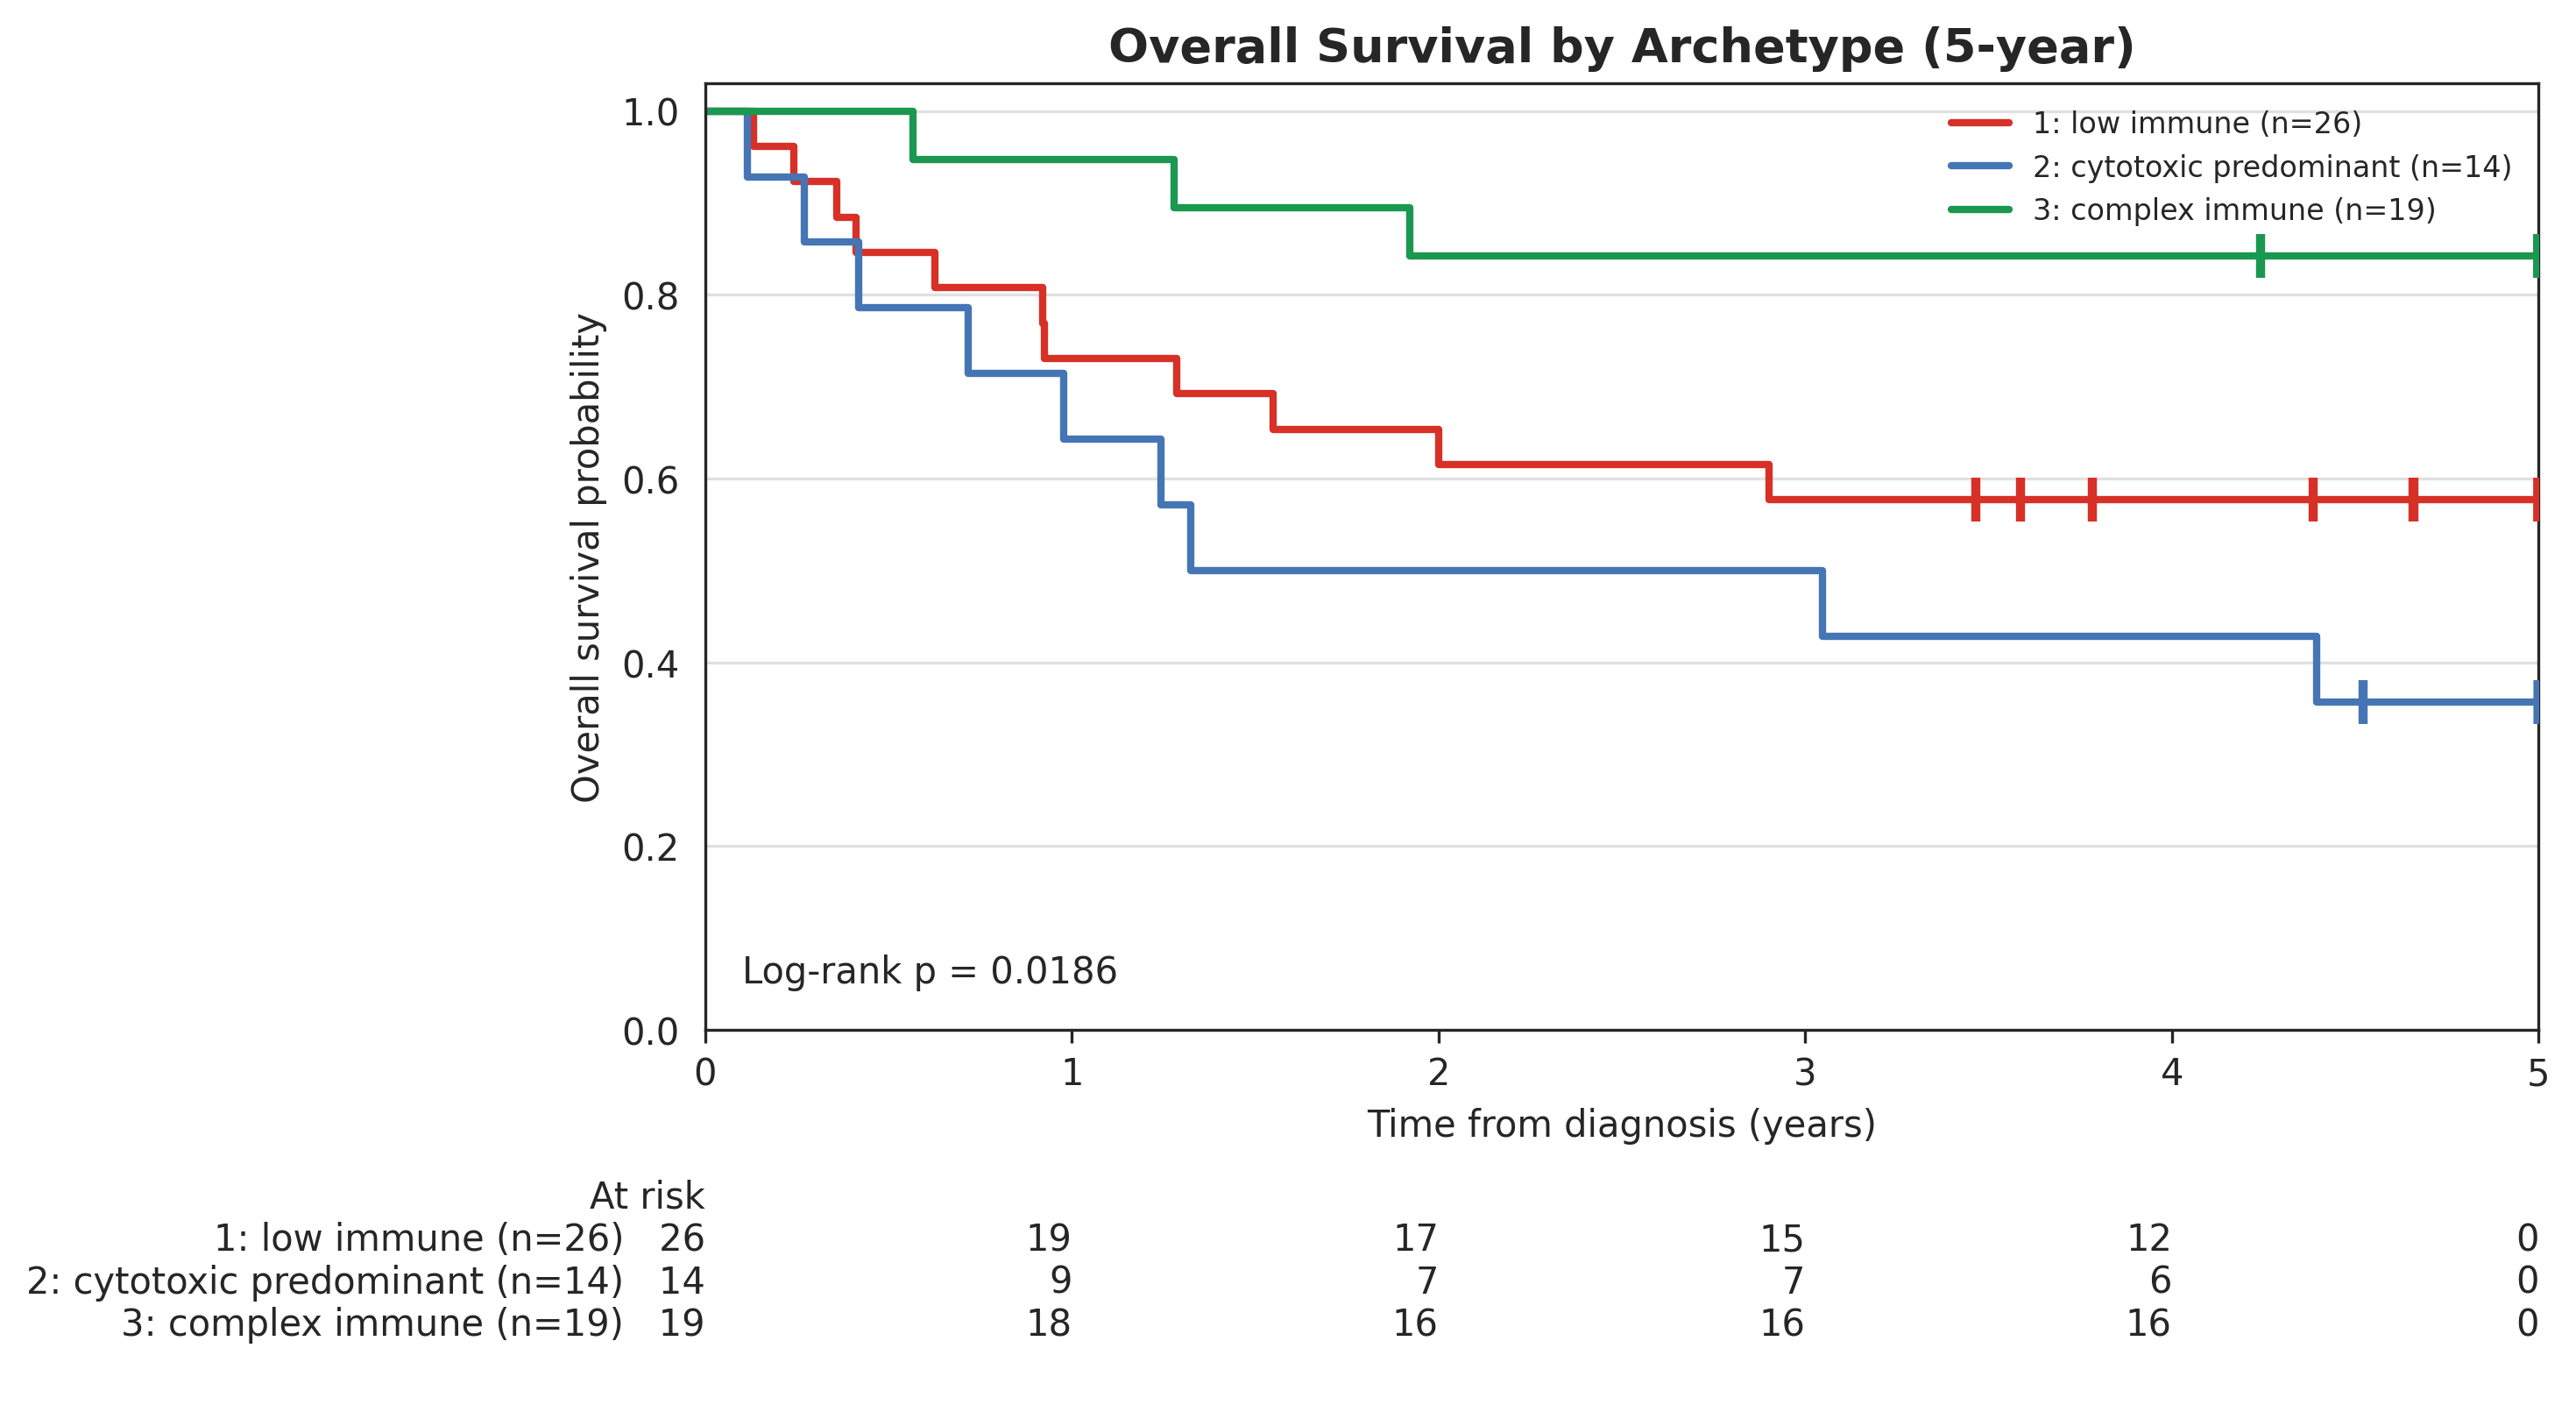

Wrote figures/fig2/fig2F_km_os_archetype.svg


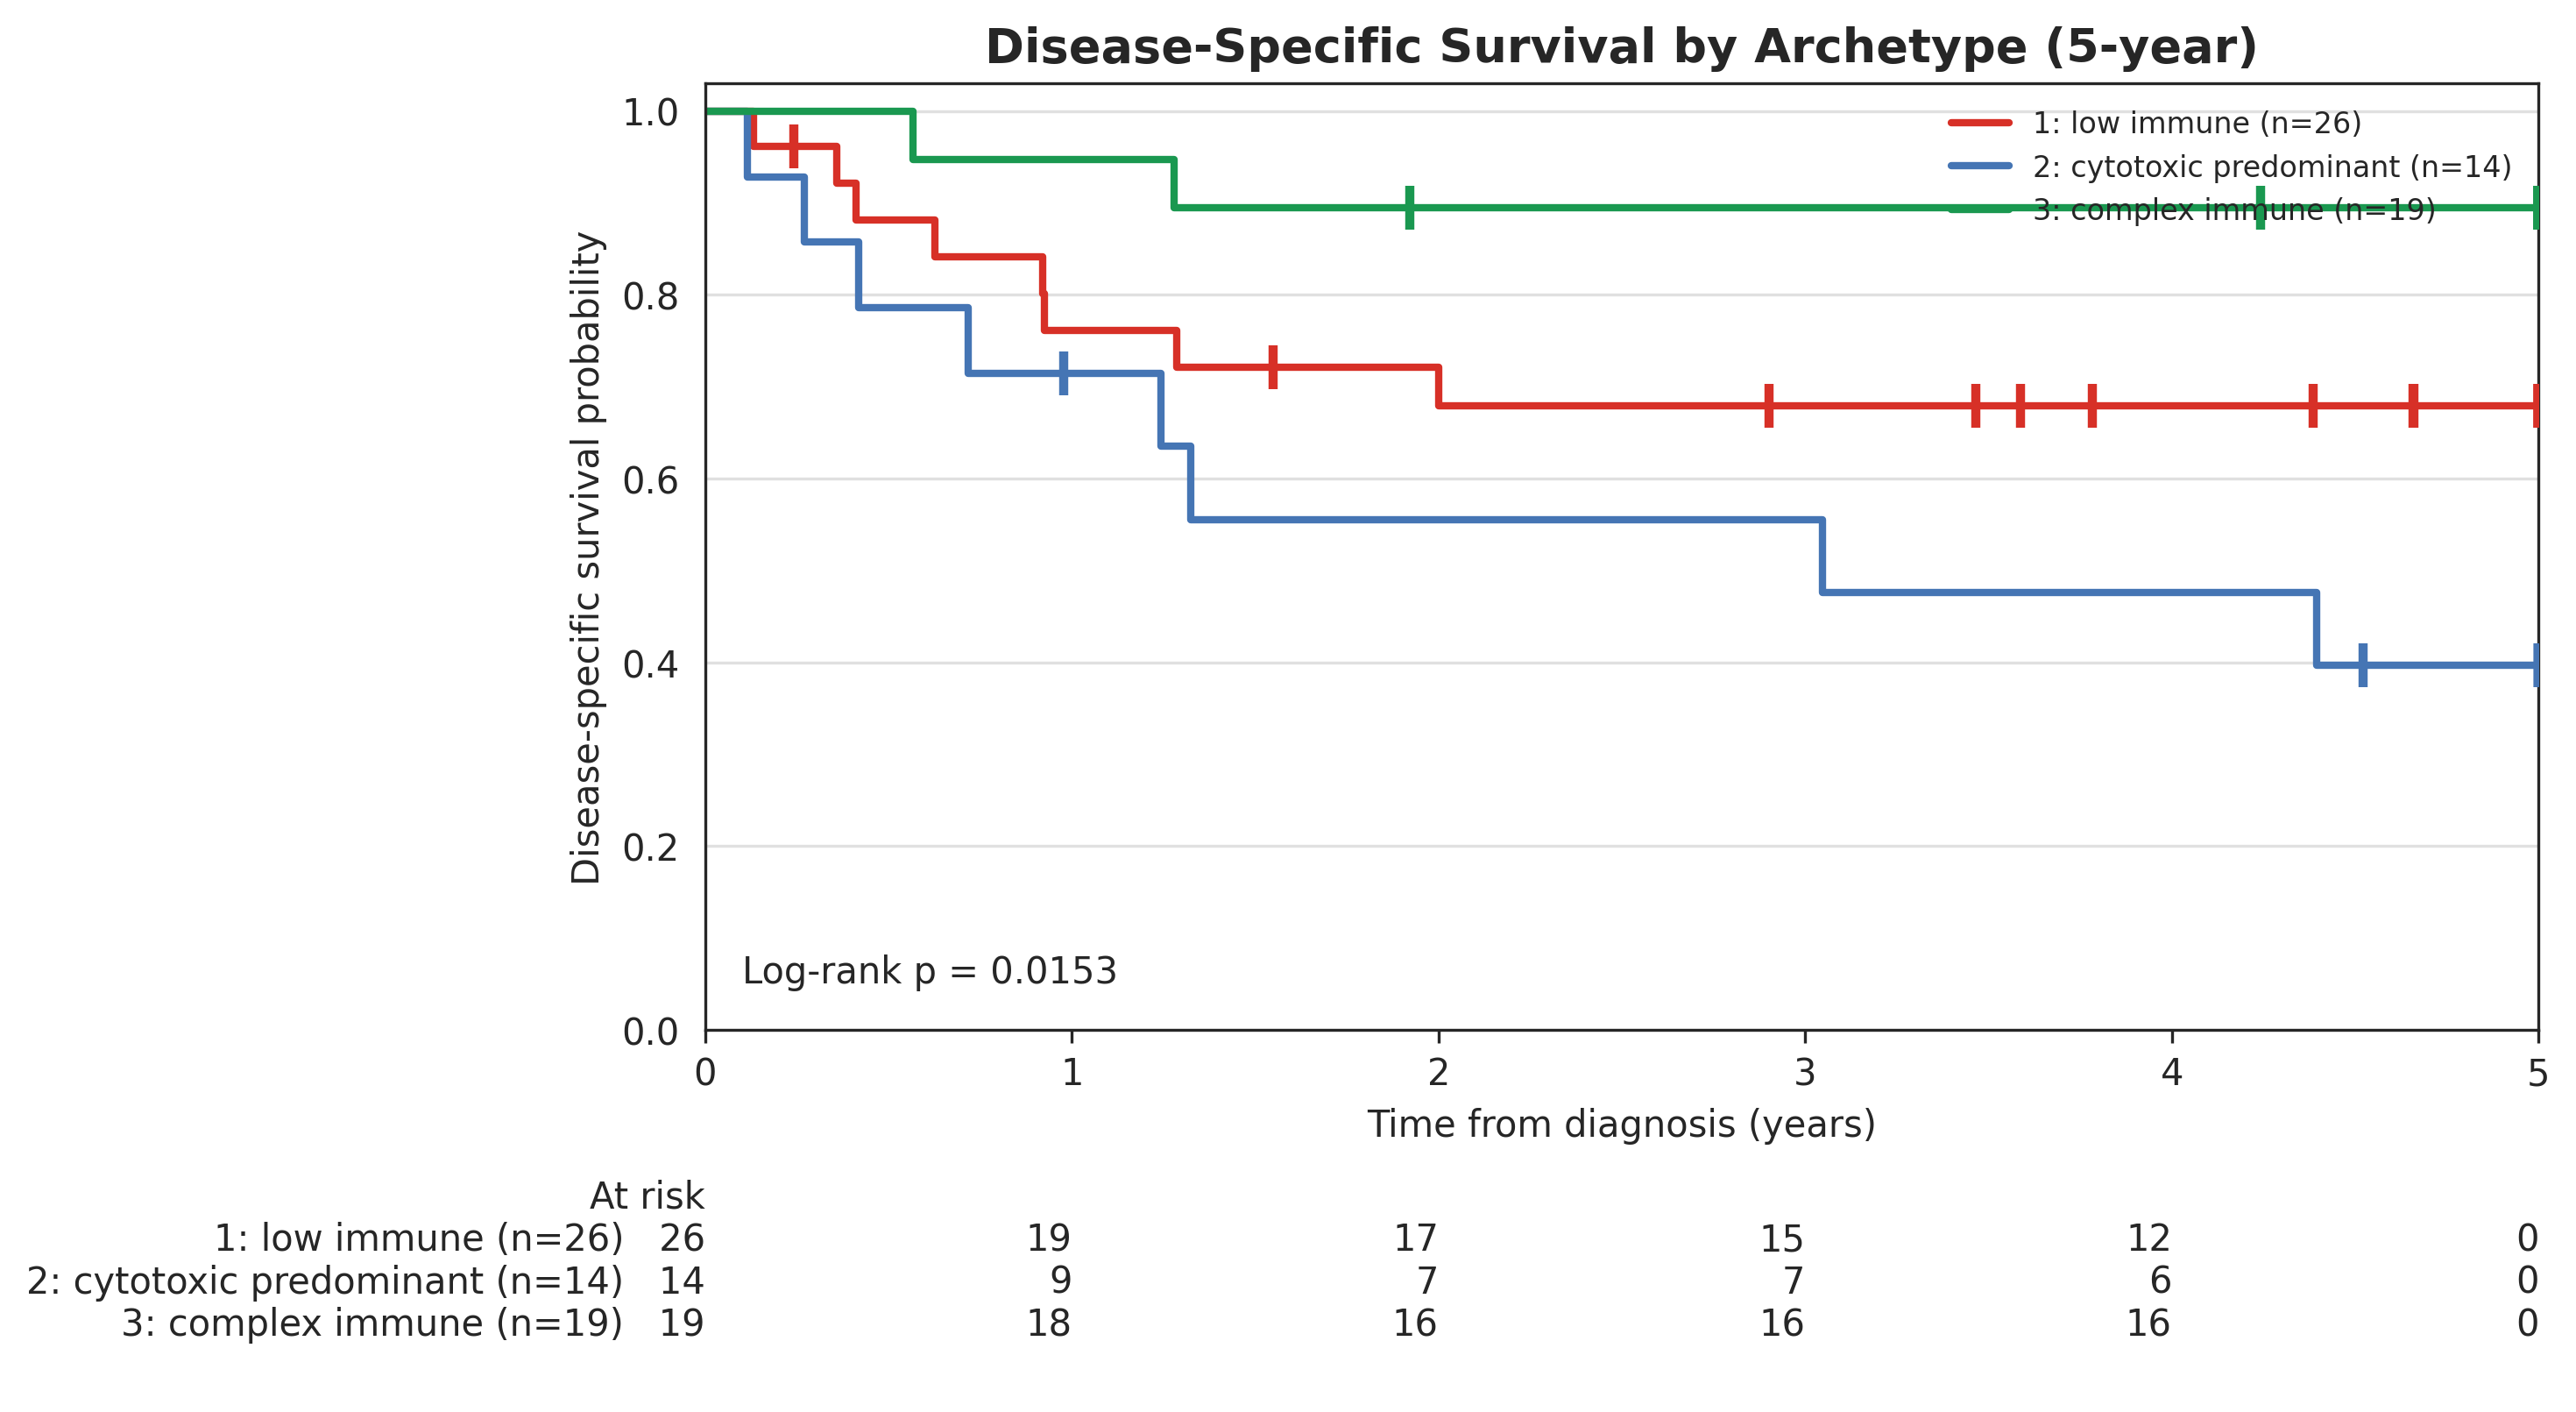

Wrote figures/fig2/fig2G_km_dss_archetype.svg


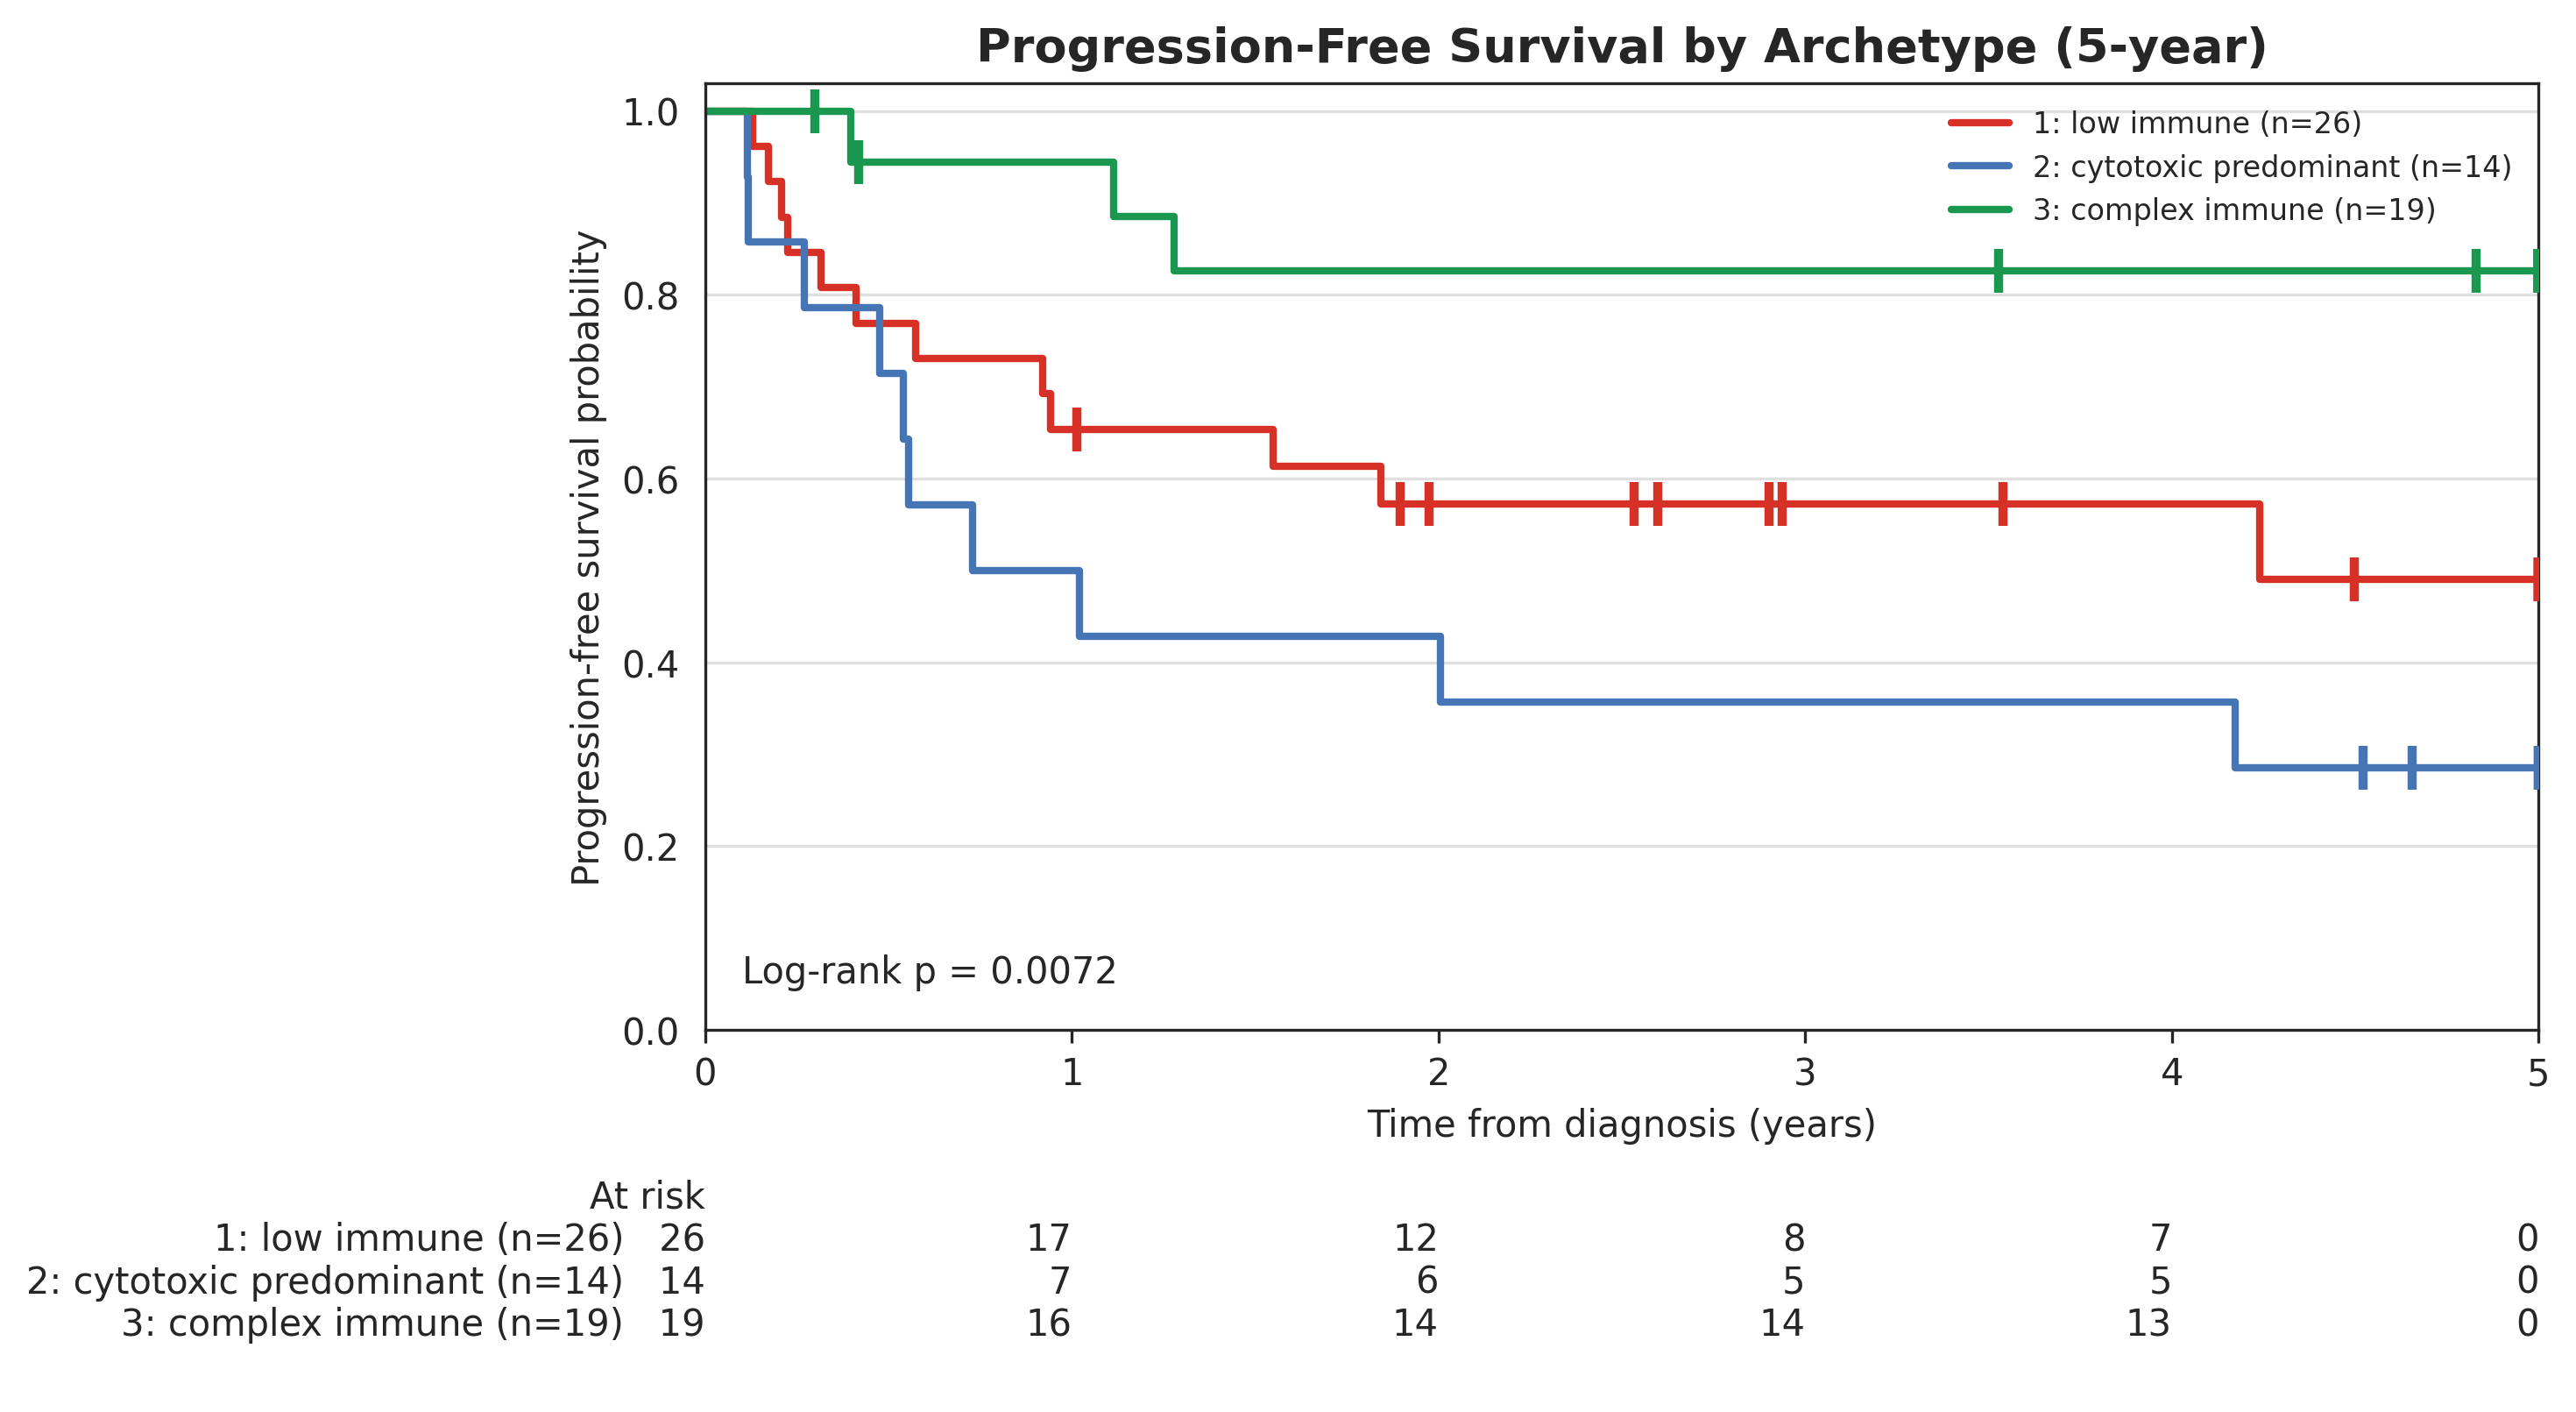

Wrote figures/fig2/figS_supp_km_pfs_archetype.svg


In [17]:
arch_os = plot_km_by_archetype(
    surv,
    time_col=ENDPOINTS["OS"]["time"],
    event_col=ENDPOINTS["OS"]["event"],
    title=f"Overall Survival by Archetype ({int(KM_HORIZON_YEARS)}-year)",
    ylabel="Overall survival probability",
    out_path=FIG_DIR / "fig2F_km_os_archetype.svg",
)
arch_dss = plot_km_by_archetype(
    surv,
    time_col=ENDPOINTS["DSS"]["time"],
    event_col=ENDPOINTS["DSS"]["event"],
    title=f"Disease-Specific Survival by Archetype ({int(KM_HORIZON_YEARS)}-year)",
    ylabel="Disease-specific survival probability",
    out_path=FIG_DIR / "fig2G_km_dss_archetype.svg",
)
arch_pfs = plot_km_by_archetype(
    surv,
    time_col=ENDPOINTS["PFS"]["time"],
    event_col=ENDPOINTS["PFS"]["event"],
    title=f"Progression-Free Survival by Archetype ({int(KM_HORIZON_YEARS)}-year)",
    ylabel="Progression-free survival probability",
    out_path=FIG_DIR / "figS_supp_km_pfs_archetype.svg",
)
arch_os.to_csv(FIG_DIR / "fig2F_km_os_archetype_summary.csv", index=False)
arch_dss.to_csv(FIG_DIR / "fig2G_km_dss_archetype_summary.csv", index=False)
arch_pfs.to_csv(FIG_DIR / "figS_supp_km_pfs_archetype_summary.csv", index=False)
